In [ ]:
import sys
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install python-math
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install scikit-learn
!{sys.executable} -m pip install seaborn

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd 
import math 
import numpy as np 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, multilabel_confusion_matrix
import seaborn as sns
import matplotlib.style
import matplotlib as mpl
mpl.style.use('default')

## 1. Functions

In [50]:
def load_excel(file_name, sheet_name):
    df = pd.read_excel(file_name,
                  true_values='Yes',
                  false_values='No',
                  sheet_name=sheet_name)
    df = df.fillna('')  
    return df

def plot_confusion_matrix(y_true,y_pred,labels,xlab='Model prediction',ylab='Manual label',figsize=(9,6),xrot=45,yrot=0,filename='',font_scale=1.5):

    sns.set_theme(font_scale=font_scale, style='white') 
    
    y_true[y_true==''] = 'None'
    y_true[y_true=='NA'] = 'None'
    y_pred[y_pred==''] = 'None'
    y_pred[y_pred=='NA'] = 'None'
    
    cm = confusion_matrix(y_true,y_pred, labels=labels)

    # calculate column sums (for calculating % & plot annotations)
    cm_sum = np.sum(cm, axis=0, keepdims=True)
    # calculate proportions
    cm_perc = cm / cm_sum.astype(float) * 100
    cm_perc[np.isnan(cm_perc)] = 0.0
    # empty array for holding annotations for each cell in the heatmap
    annot = np.empty_like(cm).astype(str)
    # get the dimensions
    nrows, ncols = cm.shape
    # cycle over cells and create annotations for each cell
    for i in range(ncols):
        for j in range(nrows):
            # get the count for the cell
            c = cm[i, j]
            # get the percentage for the cell
            p = cm_perc[i, j]
            if np.isnan(p):
                p = 0.
            if i == j:
                s = cm_sum[0,i]
                # convert the proportion, count, and row sum to a string with pretty formatting
                annot[i, j] = '%.1f%%\n%d' % (p, c)
            elif c == 0:
                annot[i, j] = ''
            else:
                annot[i, j] = '%.1f%%\n%d' % (p, c)
                
    # convert the array to a dataframe. To plot by proportion instead of number, use cm_perc in the DataFrame instead of cm
    cm = pd.DataFrame(cm_perc, index=labels, columns=labels)
    cm.index.name = 'True'
    cm.columns.name = 'Pred'

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=annot, fmt='', ax=ax, cmap=plt.cm.Blues, linewidths=2., cbar=False, vmin=0, vmax=100)
    ax.tick_params(left=False, bottom=False)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xlabel(xlab, labelpad=10)
    ax.set_ylabel(ylab, labelpad=10)
    plt.xticks(rotation=xrot, ha='right')
    plt.yticks(rotation=yrot)
    
    # Add colorbar
    cbar = ax.figure.colorbar(ax.collections[0], ax=ax, orientation='vertical', pad=0.015)
    cbar.outline.set_visible(False)
    cbar.set_label('Precision', rotation=90, labelpad=10)
    

    plt.tight_layout()

    plt.savefig('confusion_matrices/%s.png'%filename,dpi=500)
    plt.show()
    print('\n')
    report = classification_report(y_true, y_pred, labels=labels, zero_division=0., digits=3)
    print(report)
    return

def plot_confusion_matrix_from_counts(tn, fp, fn, tp, labels=['Negative', 'Positive'], xlab='Model prediction', ylab='Manual label', figsize=(9,6), xrot=45, yrot=0, train_test='train', filename=''):
    
    # Manually create the confusion matrix array
    # Row 0: True Negative, False Positive | Row 1: False Negative, True Positive
    cm = np.array([[tn, fp], 
                   [fn, tp]])

    # calculate row sums
    cm_sum = np.transpose(np.sum(cm, axis=0, keepdims=True))
    # calculate proportions
    cm_perc = np.divide(cm, cm_sum.astype(float), out=np.zeros_like(cm, dtype=float), where=cm_sum!=0) * 100
    
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    
    for i in range(ncols):
        for j in range(nrows):
            c = cm[i, j]
            p = cm_perc[i, j]
            # Format annotation: Percentage and raw count
            if c == 0:
                annot[i, j] = '0.0%\n0'
            else:
                annot[i, j] = '%.1f%%\n%d' % (p, c)
                
    cm_df = pd.DataFrame(cm_perc, index=labels, columns=labels)
    cm_df.index.name = 'True'
    cm_df.columns.name = 'Pred'

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm_df, annot=annot, fmt='', ax=ax, cmap=plt.cm.Blues, linewidths=2., cbar=False, vmin=0, vmax=100)
    
    ax.set_yticklabels(labels, rotation=yrot)
    ax.set_xticklabels(labels, rotation=xrot)
    ax.set_xlabel(xlab, labelpad=10)
    ax.set_ylabel(ylab, labelpad=10)
    
    cbar = ax.figure.colorbar(ax.collections[0], ax=ax, orientation='vertical', pad=0.015)
    cbar.outline.set_visible(False)
    cbar.set_label('Precision', rotation=90, labelpad=10)

    plt.tight_layout()

    if filename:
        plt.savefig(f'confusion_matrices/{filename}_{train_test}.png', dpi=500)
    
    plt.show()

    # 5. Generate Classification Report
    # Reconstruct vectors to satisfy scikit-learn requirements
    y_true = [0] * (tn + fp) + [1] * (fn + tp)
    y_pred = [0] * tn + [1] * fp + [0] * fn + [1] * tp
    
    print('\nClassification Report:')
    report = classification_report(y_true, y_pred, target_names=labels, zero_division=0.0, digits=3)
    print(report)
    return


def compute_accuracy(manual_vec, gen_vec):
    
    #print(f"{sum(manual_vec==gen_vec)/len(manual_vec):.1%}")
    manual_vec[manual_vec==''] = 'None'
    manual_vec[manual_vec=='NA'] = 'None'
    gen_vec[gen_vec==''] = 'None'
    gen_vec[gen_vec=='NA'] = 'None'
    
    mismatches = [(i,m, g) for (i,m), g in zip(enumerate(manual_vec.tolist()), gen_vec.tolist()) if m != g]
    
    tn = sum((manual_vec==gen_vec) & (gen_vec=='None'))
    tp = sum((manual_vec==gen_vec) & (gen_vec!='None'))
    
    fn = sum((manual_vec!=gen_vec) & (gen_vec=='None')) 
    fp = sum((manual_vec!=gen_vec) & (gen_vec!='None'))

    # Calculate denominators
    total = tp + tn + fp + fn
    prec_denom = tp + fp
    rec_denom = tp + fn
    f1_denom = (2 * tp) + fp + fn

    # Safe division logic
    acc = f"{(tp + tn) / total:.1%}" if total > 0 else "NA"
    prec = f"{tp / prec_denom:.1%}" if prec_denom > 0 else "NA"
    rec = f"{tp / rec_denom:.1%}" if rec_denom > 0 else "NA"
    f1 = f"{(2 * tp) / f1_denom:.1%}" if f1_denom > 0 else "NA"

    print(f"support:   {total}")
    print(f"accuracy:  {acc}")
    print(f"precision: {prec}")
    print(f"recall:    {rec}")
    print(f"f1:        {f1}")
    
    return mismatches

## 2. Load training and test set 

In [3]:
df_train_generated = load_excel("../1_ollama-main/train_test/output-train-gpt-oss-final.xlsx", sheet_name=0)
df_train_checked = load_excel("../1_ollama-main/train_test/output-train-gpt-oss-final.xlsx", sheet_name=1)
df_train_locs = load_excel("../1_ollama-main/train_test/output-train-gpt-oss-final.xlsx", sheet_name=2)

print(len(df_train_generated))

empty_indices = df_train_generated[(df_train_generated[['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species', 'Common Name']] == '').all(axis=1)].index.tolist()

df_train_generated = df_train_generated.drop(index=empty_indices)
df_train_checked = df_train_checked.drop(index=empty_indices)
df_train_locs = df_train_locs.drop(index=empty_indices)

print(len(df_train_generated))

599
593


In [4]:
df_test_generated = load_excel("../1_ollama-main/train_test/output-test-gpt-oss-final.xlsx", sheet_name=0)
df_test_checked = load_excel("../1_ollama-main/train_test/output-test-gpt-oss-final.xlsx", sheet_name=1)
df_test_locs = load_excel("../1_ollama-main/train_test/output-test-gpt-oss-final.xlsx", sheet_name=2)

print(len(df_test_generated))

empty_indices = df_test_generated[(df_test_generated[['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species', 'Common Name']] == '').all(axis=1)].index.tolist()

df_test_generated = df_test_generated.drop(index=empty_indices)
df_test_checked = df_test_checked.drop(index=empty_indices)
df_test_locs = df_test_locs.drop(index=empty_indices)

print(len(df_test_generated))

224
211


In [5]:
# train and test combined
df_generated = pd.concat([df_train_generated, df_test_generated], ignore_index=True)
df_checked = pd.concat([df_train_checked, df_test_checked], ignore_index=True)
df_locs = pd.concat([df_train_locs, df_test_locs], ignore_index=True)

## Results: Taxonomy 

In [608]:
def analyse_taxonomy(locs, checked, generated): 

    # locations of inferred taxonomy (taxonomy not stated in the text) 
    inferred_p = locs['Phylum']==1
    inferred_c = locs['Class']==1
    inferred_o = locs['Order']==1
    inferred_f = locs['Family']==1

    # locations of non-inferred taxonomy (taxonomy stated in the text) 
    noninferred_p = locs['Phylum'].isin([0,2,3])
    noninferred_c = locs['Class'].isin([0,2,3])
    noninferred_o = locs['Order'].isin([0,2,3])
    noninferred_f = locs['Family'].isin([0,2,3])
    noninferred_g = locs['Genus'].isin([0,2,3])
    noninferred_s = locs['Species'].isin([0,2,3])

    # locations of taxonomic corrections 
    correction_p = locs['Phylum']==3
    correction_c = locs['Class']==3
    correction_o = locs['Order']==3
    correction_f = locs['Family']==3
    correction_g = locs['Genus']==3
    correction_s = locs['Species']==3

    # locations of missed taxonomic corrections
    missed_correction_p = locs['Phylum']==2
    missed_correction_c = locs['Class']==2
    missed_correction_o = locs['Order']==2
    missed_correction_f = locs['Family']==2
    missed_correction_g = locs['Genus']==2
    missed_correction_s = locs['Species']==2

    # 1. inferred 
    print("\n1. Inferred taxonomy:\n")
    
    acc_p = sum(generated.loc[inferred_p]['Phylum'] == checked.loc[inferred_p]['Phylum'])/sum(inferred_p)
    acc_c = sum(generated.loc[inferred_c]['Class'] == checked.loc[inferred_c]['Class'])/sum(inferred_c)
    acc_o = sum(generated.loc[inferred_o]['Order'] == checked.loc[inferred_o]['Order'])/sum(inferred_o)
    acc_f = sum(generated.loc[inferred_f]['Family'] == checked.loc[inferred_f]['Family'])/sum(inferred_f)
    
    print('Phylum:  ', round(100*acc_p,1))
    print('Class:   ', round(100*acc_c,1))
    print('Order:   ', round(100*acc_o,1))
    print('Family:  ', round(100*acc_f,1))

    print("\nHow many of the total errors were blank predictions?\n")
    
    errs_tot_p = sum(generated.loc[inferred_p]['Phylum'] != checked.loc[inferred_p]['Phylum'])
    errs_blank_p = sum(generated[generated['Phylum']==""].loc[inferred_p]['Phylum'] != checked[generated['Phylum']==""].loc[inferred_p]['Phylum'])
    
    errs_tot_c = sum(generated.loc[inferred_c]['Class'] != checked.loc[inferred_c]['Class'])
    errs_blank_c = sum(generated[generated['Class']==""].loc[inferred_c]['Class'] != checked[generated['Class']==""].loc[inferred_c]['Class'])
    
    errs_tot_o = sum(generated.loc[inferred_o]['Order'] != checked.loc[inferred_o]['Order'])
    errs_blank_o = sum(generated[generated['Order']==""].loc[inferred_o]['Order'] != checked[generated['Order']==""].loc[inferred_o]['Order'])
    
    errs_tot_f = sum(generated.loc[inferred_f]['Family'] != checked.loc[inferred_f]['Family'])
    errs_blank_f = sum(generated[generated['Family']==""].loc[inferred_f]['Family'] != checked[generated['Family']==""].loc[inferred_f]['Family'])
    
    print(errs_blank_p, '/', errs_tot_p)#, '\t=', errs_blank_p/errs_tot_p)
    print(errs_blank_c, '/', errs_tot_c)#, '\t=', errs_blank_c/errs_tot_c)
    print(errs_blank_o, '/', errs_tot_o)#, '\t=', errs_blank_o/errs_tot_o)
    print(errs_blank_f, '/', errs_tot_f)#, '\t=', errs_blank_f/errs_tot_f)
    
    print("\nFamily accuracy without blank errors:")
    
    acc_f = (sum(generated.loc[inferred_f]['Family'] == checked.loc[inferred_f]['Family']) + errs_blank_f)/sum(inferred_f)
    
    print('Family:  ', round(100*acc_f,1))

    # 2. non-inferred
    print("\n2. Non-inferred taxonomy:\n")
    
    acc_p = sum(generated.loc[noninferred_p]['Phylum'] == checked.loc[noninferred_p]['Phylum'])/sum(noninferred_p)
    acc_c = sum(generated.loc[noninferred_c]['Class'] == checked.loc[noninferred_c]['Class'])/sum(noninferred_c)
    acc_o = sum(generated.loc[noninferred_o]['Order'] == checked.loc[noninferred_o]['Order'])/sum(noninferred_o)
    acc_f = sum(generated.loc[noninferred_f]['Family'] == checked.loc[noninferred_f]['Family'])/sum(noninferred_f)
    acc_g = sum(generated.loc[noninferred_g]['Genus'] == checked.loc[noninferred_g]['Genus'])/sum(noninferred_g)
    acc_s = sum(generated.loc[noninferred_s]['Species'] == checked.loc[noninferred_s]['Species'])/sum(noninferred_s)
    
    print('Phylum:  ', round(100*acc_p,1))
    print('Class:   ', round(100*acc_c,1))
    print('Order:   ', round(100*acc_o,1))
    print('Family:  ', round(100*acc_f,1))
    print('Genus:   ', round(100*acc_g,1))
    print('Species: ', round(100*acc_s,1))
    
    # how many manual corrections were there? 

    corrections_p = len(generated.loc[correction_p | missed_correction_p]['Order'])
    corrections_c = len(generated.loc[correction_c | missed_correction_c]['Order'])
    corrections_o = len(generated.loc[correction_o | missed_correction_o]['Order'])
    corrections_f = len(generated.loc[correction_f | missed_correction_f]['Family'])
    corrections_g = len(generated.loc[correction_g | missed_correction_g]['Genus'])
    corrections_s = len(generated.loc[correction_s | missed_correction_s]['Species'])
    
    # how many were addressed correctly? 

    addressed_p = len(generated.loc[correction_p]['Phylum'])
    addressed_c = len(generated.loc[correction_c]['Class'])
    addressed_o = len(generated.loc[correction_o]['Order'])
    addressed_f = len(generated.loc[correction_f]['Family'])
    addressed_g = len(generated.loc[correction_g]['Genus'])
    addressed_s = len(generated.loc[correction_s]['Species'])
    
    print("\nHow many manual corrections were adressed correctly?\n")
    print(addressed_p, '/', corrections_p)#, '\t=', addressed_p/corrections_p)
    print(addressed_c, '/', corrections_c)#, '\t=', addressed_c/corrections_c)
    print(addressed_o, '/', corrections_o)#, '\t=', addressed_o/corrections_o)
    print(addressed_f, '/', corrections_f)#, '\t\t=', addressed_f/corrections_f)
    print(addressed_g, '/', corrections_g)#, '\t\t=', addressed_g/corrections_g)
    print(addressed_s, '/', corrections_s)#, '\t\t=', addressed_s/corrections_s)
    
    
    # accuracy without the unaddressed corrections: 
    
    acc_p = sum(generated.loc[noninferred_p]['Phylum'] == checked.loc[noninferred_p]['Phylum'])/sum(noninferred_p)
    acc_c = sum(generated.loc[noninferred_c]['Class'] == checked.loc[noninferred_c]['Class'])/sum(noninferred_c)
    acc_o = sum(generated.loc[noninferred_o]['Order'] == checked.loc[noninferred_o]['Order'])/sum(noninferred_o)
    acc_f = sum(generated.loc[noninferred_f]['Family'] == checked.loc[noninferred_f]['Family'])/sum(noninferred_f)
    acc_g = (sum(generated.loc[noninferred_g]['Genus'] == checked.loc[noninferred_g]['Genus'])+corrections_g-addressed_g)/sum(noninferred_g)
    acc_s = (sum(generated.loc[noninferred_s]['Species'] == checked.loc[noninferred_s]['Species'])+corrections_s-addressed_s)/sum(noninferred_s)
    
    print('\nAccuracy without the unaddressed corrections:\n')
    print('Phylum:  ', round(100*acc_p,1))
    print('Class:   ', round(100*acc_c,1))
    print('Order:   ', round(100*acc_o,1))
    print('Family:  ', round(100*acc_f,1))
    print('Genus:   ', round(100*acc_g,1))
    print('Species: ', round(100*acc_s,1))
    
    # 3. overall 
    print("\n3. Overall:\n")
    
    acc_p = sum(generated['Phylum'] == checked['Phylum'])/len(generated)
    acc_c = sum(generated['Class'] == checked['Class'])/len(generated)
    acc_o = sum(generated['Order'] == checked['Order'])/len(generated)
    acc_f = sum(generated['Family'] == checked['Family'])/len(generated)
    acc_g = sum(generated['Genus'] == checked['Genus'])/len(generated)
    acc_s = sum(generated['Species'] == checked['Species'])/len(generated)
    
    print('Phylum:  ', round(100*acc_p,1))
    print('Class:   ', round(100*acc_c,1))
    print('Order:   ', round(100*acc_o,1))
    print('Family:  ', round(100*acc_f,1))
    print('Genus:   ', round(100*acc_g,1))
    print('Species: ', round(100*acc_s,1))

    # overall (without blank errors and unaddressed corrections)
    print("\n4. Overall (without blank errors and unaddressed corrections):\n")

    acc_p = sum(generated['Phylum'] == checked['Phylum'])/len(generated)
    acc_c = sum(generated['Class'] == checked['Class'])/len(generated)
    acc_o = sum(generated['Order'] == checked['Order'])/len(generated)
    acc_f = (sum(generated['Family'] == checked['Family'])+errs_blank_f)/len(generated)
    acc_g = (sum(generated['Genus'] == checked['Genus'])+corrections_g-addressed_g)/len(generated)
    acc_s = (sum(generated['Species'] == checked['Species'])+corrections_s-addressed_s)/len(generated)
    
    print('Phylum:  ', round(100*acc_p,1))
    print('Class:   ', round(100*acc_c,1))
    print('Order:   ', round(100*acc_o,1))
    print('Family:  ', round(100*acc_f,1))
    print('Genus:   ', round(100*acc_g,1))
    print('Species: ', round(100*acc_s,1))

    # # vectors
    # gen_p, check_p = generated['Phylum'].copy(), checked['Phylum'].copy()
    # gen_c, check_c = generated['Class'].copy(), checked['Class'].copy()
    # gen_o, check_o = generated['Order'].copy(), checked['Order'].copy()
    # gen_f, check_f = generated['Family'].copy(), checked['Family'].copy()
    # gen_g, check_g = generated['Genus'].copy(), checked['Genus'].copy()
    # gen_s, check_s = generated['Species'].copy(), checked['Species'].copy()

    
    # check_f[gen_f==""].loc[inferred_f] = gen_f[gen_f==""].loc[inferred_f] # remove blank errors 
    # check_p.loc[missed_correction_p] = gen_p.loc[missed_correction_p] # remove errors due to manual corrections 
    # check_c.loc[missed_correction_c] = gen_c.loc[missed_correction_c] # remove errors due to manual corrections 
    # check_o.loc[missed_correction_o] = gen_o.loc[missed_correction_o] # remove errors due to manual corrections 
    # check_f.loc[missed_correction_f] = gen_f.loc[missed_correction_f] # remove errors due to manual corrections 
    # check_g.loc[missed_correction_g] = gen_g.loc[missed_correction_g] # remove errors due to manual corrections 
    # check_s.loc[missed_correction_s] = gen_s.loc[missed_correction_s] # remove errors due to manual corrections 

    # print("\n")
    # mismatches = compute_accuracy(gen_p, check_p)
    # print("\n",mismatches)

    # mismatches = compute_accuracy(gen_c, check_c)
    # print("\n",mismatches)

    # mismatches = compute_accuracy(gen_o, check_o)
    # print("\n",mismatches)

    # mismatches = compute_accuracy(gen_f, check_f)
    # print("\n",mismatches)

    # mismatches = compute_accuracy(gen_g, check_g)
    # print("\n",mismatches)

    # mismatches = compute_accuracy(gen_s, check_s)
    # print("\n",mismatches)

    return 

### Train

In [609]:
analyse_taxonomy(df_train_locs, df_train_checked, df_train_generated)


1. Inferred taxonomy:

Phylum:   95.3
Class:    99.4
Order:    98.7
Family:   81.8

How many of the total errors were blank predictions?

0 / 25
0 / 2
0 / 2
7 / 18

Family accuracy without blank errors:
Family:   88.9

2. Non-inferred taxonomy:

Phylum:   100.0
Class:    100.0
Order:    100.0
Family:   99.8
Genus:    99.0
Species:  98.1

How many manual corrections were adressed correctly?

0 / 0
0 / 0
13 / 13
1 / 1
2 / 6
8 / 12

Accuracy without the unaddressed corrections:

Phylum:   100.0
Class:    100.0
Order:    100.0
Family:   99.8
Genus:    99.7
Species:  98.8

3. Overall:

Phylum:   95.8
Class:    99.7
Order:    99.7
Family:   96.8
Genus:    99.0
Species:  98.1

4. Overall (without blank errors and unaddressed corrections):

Phylum:   95.8
Class:    99.7
Order:    99.7
Family:   98.0
Genus:    99.7
Species:  98.8


In [610]:
# common names - TRAIN

manual_vec = df_train_checked['Common Name']
gen_vec = df_train_generated['Common Name']

mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   593
accuracy:  82.3%
precision: 35.2%
recall:    100.0%
f1:        52.1%


[(4, 'None', 'carabid beetle'),
 (5, 'None', 'ground beetle'),
 (6, 'None', 'ground beetle'),
 (7, 'None', 'ground beetle'),
 (25, 'None', 'ground beetle'),
 (26, 'None', 'ground beetle'),
 (27, 'None', 'ground beetle'),
 (28, 'None', 'insidious flower bug'),
 (30, 'None', 'mirid bug'),
 (31, 'None', 'dustywing'),
 (34, 'None', 'braconid parasitoid wasp'),
 (35, 'None', 'tachinid fly (parasitoid)'),
 (36, 'None', 'ground beetles'),
 (37, 'None', 'ground beetles'),
 (39, 'None', 'ground beetle'),
 (52, 'None', 'ground beetle'),
 (62, 'None', 'Entomopathogenic nematode'),
 (63, 'None', 'European pine weevil'),
 (64, 'None', 'North‑American pine weevil'),
 (79, 'None', 'grasshopper'),
 (80, 'None', 'ground beetle'),
 (81, 'None', 'ground beetle'),
 (87, 'None', 'White-marked tussock moth'),
 (88, 'None', 'Yellow-spotted tussock moth'),
 (89, 'None', 'Virginia tiger moth'),
 (97, 'None', 'predatory stink bug'),
 (99, 'None', 'spruce bud moth'),
 (110, 'None', 'ground beetle'),
 (111, 'None

In [11]:
# synonyms - TRAIN

manual_vec = df_train_checked['Synonyms']
gen_vec = df_train_generated['Synonyms']

mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   593
accuracy:  100.0%
precision: 100.0%
recall:    100.0%
f1:        100.0%


[]

### Test

In [611]:
analyse_taxonomy(df_test_locs, df_test_checked, df_test_generated)


1. Inferred taxonomy:

Phylum:   94.0
Class:    93.4
Order:    97.8
Family:   91.8

How many of the total errors were blank predictions?

0 / 11
0 / 9
0 / 2
2 / 7

Family accuracy without blank errors:
Family:   94.1

2. Non-inferred taxonomy:

Phylum:   100.0
Class:    100.0
Order:    100.0
Family:   99.2
Genus:    100.0
Species:  100.0

How many manual corrections were adressed correctly?

0 / 0
0 / 0
5 / 5
1 / 1
0 / 0
0 / 0

Accuracy without the unaddressed corrections:

Phylum:   100.0
Class:    100.0
Order:    100.0
Family:   99.2
Genus:    100.0
Species:  100.0

3. Overall:

Phylum:   94.8
Class:    95.7
Order:    99.1
Family:   96.2
Genus:    100.0
Species:  100.0

4. Overall (without blank errors and unaddressed corrections):

Phylum:   94.8
Class:    95.7
Order:    99.1
Family:   97.2
Genus:    100.0
Species:  100.0


In [612]:
# common names - TEST

manual_vec = df_test_checked['Common Name']
gen_vec = df_test_generated['Common Name']

mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   211
accuracy:  96.7%
precision: 94.0%
recall:    100.0%
f1:        96.9%


[(5, 'None', 'freshwater snail'),
 (6, 'None', 'Flesh fly'),
 (8, 'None', 'Damsel bug'),
 (24, 'None', 'parasitoid wasp'),
 (29, 'None', 'parasitoid wasp'),
 (31, 'None', 'Entomopathogenic nematode'),
 (32, 'None', 'Entomopathogenic nematode')]

In [17]:
# synonyms - TEST

manual_vec = df_test_checked['Synonyms']
gen_vec = df_test_generated['Synonyms']

mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   211
accuracy:  97.2%
precision: 0.0%
recall:    NA
f1:        0.0%


[(87, 'None', 'Trichomalus perfectus'),
 (88, 'None', 'Mesopolobus morys'),
 (89, 'None', 'Stenomalina gracilis'),
 (90, 'None', 'Trichomalus fasciatus'),
 (91, 'None', 'Xenocrepis pura'),
 (92, 'None', 'Habrocytus sp.')]

### Total

In [614]:
analyse_taxonomy(df_locs, df_checked, df_generated)


1. Inferred taxonomy:

Phylum:   94.9
Class:    97.8
Order:    98.4
Family:   86.4

How many of the total errors were blank predictions?

0 / 36
0 / 11
0 / 4
9 / 25

Family accuracy without blank errors:
Family:   91.3

2. Non-inferred taxonomy:

Phylum:   100.0
Class:    100.0
Order:    100.0
Family:   99.7
Genus:    99.3
Species:  98.6

How many manual corrections were adressed correctly?

0 / 0
0 / 0
18 / 18
2 / 2
2 / 6
8 / 12

Accuracy without the unaddressed corrections:

Phylum:   100.0
Class:    100.0
Order:    100.0
Family:   99.7
Genus:    99.8
Species:  99.1

3. Overall:

Phylum:   95.5
Class:    98.6
Order:    99.5
Family:   96.6
Genus:    99.3
Species:  98.6

4. Overall (without blank errors and unaddressed corrections):

Phylum:   95.5
Class:    98.6
Order:    99.5
Family:   97.8
Genus:    99.8
Species:  99.1


In [615]:
# common names - TOTAL

manual_vec = df_checked['Common Name']
gen_vec = df_generated['Common Name']

mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   804
accuracy:  86.1%
precision: 59.9%
recall:    100.0%
f1:        74.9%


[(4, 'None', 'carabid beetle'),
 (5, 'None', 'ground beetle'),
 (6, 'None', 'ground beetle'),
 (7, 'None', 'ground beetle'),
 (25, 'None', 'ground beetle'),
 (26, 'None', 'ground beetle'),
 (27, 'None', 'ground beetle'),
 (28, 'None', 'insidious flower bug'),
 (30, 'None', 'mirid bug'),
 (31, 'None', 'dustywing'),
 (34, 'None', 'braconid parasitoid wasp'),
 (35, 'None', 'tachinid fly (parasitoid)'),
 (36, 'None', 'ground beetles'),
 (37, 'None', 'ground beetles'),
 (39, 'None', 'ground beetle'),
 (52, 'None', 'ground beetle'),
 (62, 'None', 'Entomopathogenic nematode'),
 (63, 'None', 'European pine weevil'),
 (64, 'None', 'North‑American pine weevil'),
 (79, 'None', 'grasshopper'),
 (80, 'None', 'ground beetle'),
 (81, 'None', 'ground beetle'),
 (87, 'None', 'White-marked tussock moth'),
 (88, 'None', 'Yellow-spotted tussock moth'),
 (89, 'None', 'Virginia tiger moth'),
 (97, 'None', 'predatory stink bug'),
 (99, 'None', 'spruce bud moth'),
 (110, 'None', 'ground beetle'),
 (111, 'None

In [18]:
# synonyms - TOTAL

manual_vec = df_checked['Synonyms']
gen_vec = df_generated['Synonyms']

mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   804
accuracy:  99.3%
precision: 64.7%
recall:    100.0%
f1:        78.6%


[(680, 'None', 'Trichomalus perfectus'),
 (681, 'None', 'Mesopolobus morys'),
 (682, 'None', 'Stenomalina gracilis'),
 (683, 'None', 'Trichomalus fasciatus'),
 (684, 'None', 'Xenocrepis pura'),
 (685, 'None', 'Habrocytus sp.')]

In [29]:
manual_vec[manual_vec!='None']

13     Phanaulax levituberculatus
15       Stenobracon trifasciatus
50              Iphiaulax morleyi
51            Iphiaulax rubriceps
218               Chilo partellns
248            Apanteles ruficrus
524               Leucopis fiorii
529             Leucopis alticeps
530            Leucopis armillata
531         Leucopis ballestrerii
534         Ochtiphila obscuripes
Name: Synonyms, dtype: object

In [30]:
gen_vec[gen_vec!='None']

13     Phanaulax levituberculatus
15       Stenobracon trifasciatus
50              Iphiaulax morleyi
51            Iphiaulax rubriceps
218               Chilo partellns
248            Apanteles ruficrus
524               Leucopis fiorii
529             Leucopis alticeps
530            Leucopis armillata
531         Leucopis ballestrerii
534         Ochtiphila obscuripes
680         Trichomalus perfectus
681             Mesopolobus morys
682          Stenomalina gracilis
683         Trichomalus fasciatus
684               Xenocrepis pura
685                Habrocytus sp.
Name: Synonyms, dtype: object

In [31]:
11/17

0.6470588235294118

## Results: Species Types and Feeding Mode

support:   593
accuracy:  99.8%
precision: 99.8%
recall:    100.0%
f1:        99.9%


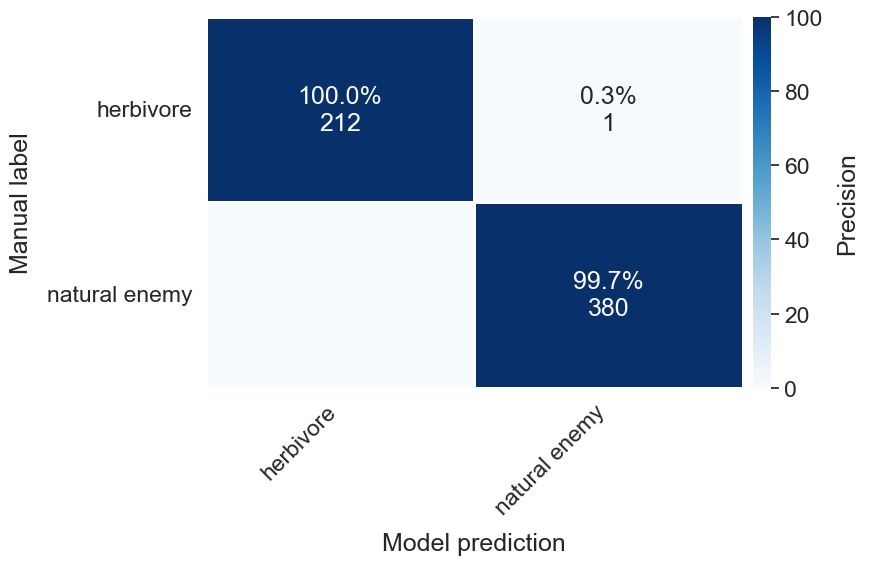



               precision    recall  f1-score   support

    herbivore      1.000     0.995     0.998       213
natural enemy      0.997     1.000     0.999       380

     accuracy                          0.998       593
    macro avg      0.999     0.998     0.998       593
 weighted avg      0.998     0.998     0.998       593



[(415, 'herbivore', 'natural enemy')]

In [7]:
# TYPES - TRAIN

mismatches = compute_accuracy(df_train_checked['Type'], df_train_generated['Type'])

plot_confusion_matrix(df_train_checked['Type'], 
                      df_train_generated['Type'],
                      labels=['herbivore','natural enemy'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_types_train')
mismatches

support:   211
accuracy:  100.0%
precision: 100.0%
recall:    100.0%
f1:        100.0%


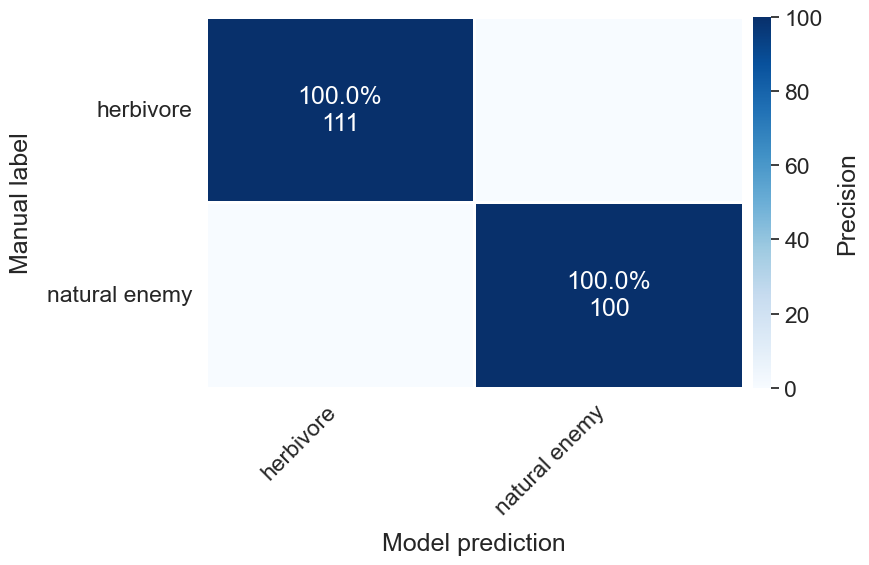



               precision    recall  f1-score   support

    herbivore      1.000     1.000     1.000       111
natural enemy      1.000     1.000     1.000       100

     accuracy                          1.000       211
    macro avg      1.000     1.000     1.000       211
 weighted avg      1.000     1.000     1.000       211



[]

In [8]:
# TYPES - TEST

mismatches = compute_accuracy(df_test_checked['Type'], df_test_generated['Type'])

plot_confusion_matrix(df_test_checked['Type'],
                      df_test_generated['Type'], 
                      labels=['herbivore','natural enemy'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_types_test')
mismatches

support:   804
accuracy:  99.9%
precision: 99.9%
recall:    100.0%
f1:        99.9%


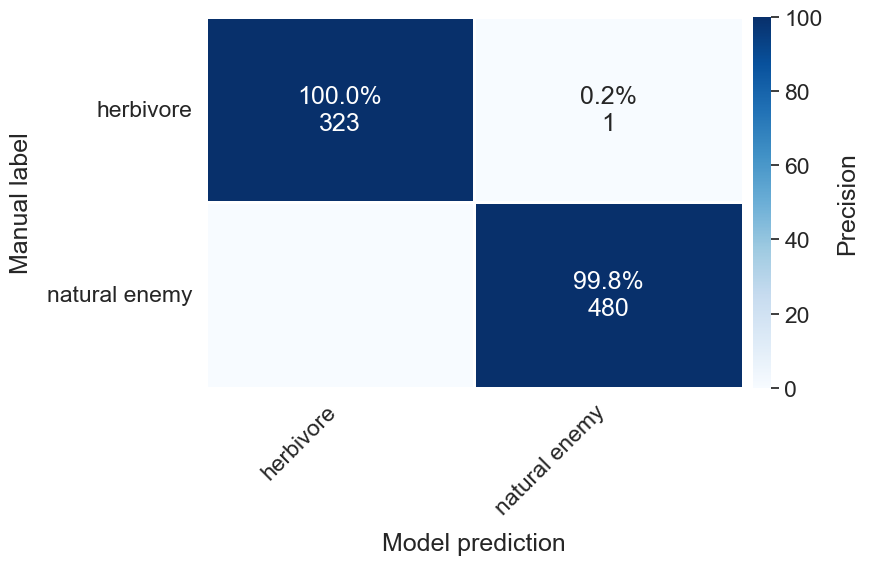



               precision    recall  f1-score   support

    herbivore      1.000     0.997     0.998       324
natural enemy      0.998     1.000     0.999       480

     accuracy                          0.999       804
    macro avg      0.999     0.998     0.999       804
 weighted avg      0.999     0.999     0.999       804



[(415, 'herbivore', 'natural enemy')]

In [9]:
# TYPES - TOTAL

mismatches = compute_accuracy(df_checked['Type'], df_generated['Type'])

plot_confusion_matrix(df_checked['Type'],
                      df_generated['Type'], 
                      labels=['herbivore','natural enemy'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_types_total')
mismatches

support:   593
accuracy:  99.3%
precision: 99.5%
recall:    99.8%
f1:        99.7%


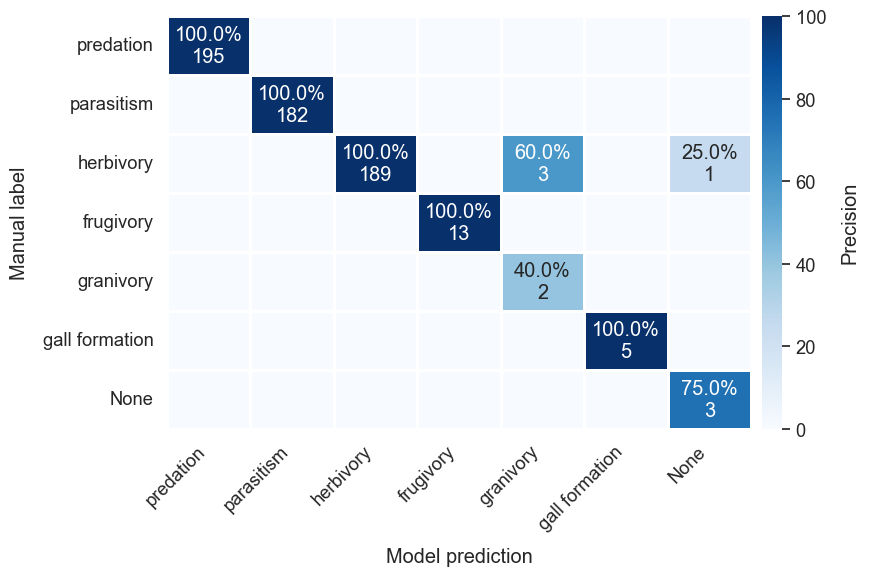



                precision    recall  f1-score   support

     predation      1.000     1.000     1.000       195
    parasitism      1.000     1.000     1.000       182
     herbivory      1.000     0.979     0.990       193
     frugivory      1.000     1.000     1.000        13
     granivory      0.400     1.000     0.571         2
gall formation      1.000     1.000     1.000         5
          None      0.750     1.000     0.857         3

      accuracy                          0.993       593
     macro avg      0.879     0.997     0.917       593
  weighted avg      0.997     0.993     0.994       593



[(387, 'herbivory', 'granivory'),
 (388, 'herbivory', 'granivory'),
 (389, 'herbivory', 'granivory'),
 (415, 'herbivory', 'None')]

In [52]:
# FEEDING MODE - TRAIN

mismatches = compute_accuracy(df_train_checked['Feeding Mode'], df_train_generated['Feeding Mode'])

plot_confusion_matrix(df_train_checked['Feeding Mode'],
                      df_train_generated['Feeding Mode'], 
                      labels=['predation','parasitism','herbivory','frugivory','granivory','gall formation', 'None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_feeding_mode_train',
                      font_scale=1.2)
mismatches

support:   211
accuracy:  100.0%
precision: 100.0%
recall:    100.0%
f1:        100.0%


/var/folders/2l/62xwcgws5mx86y0bhqmkbpqc0000gn/T/ipykernel_91043/3778784764.py:23: RuntimeWarning: invalid value encountered in divide
  cm_perc = cm / cm_sum.astype(float) * 100


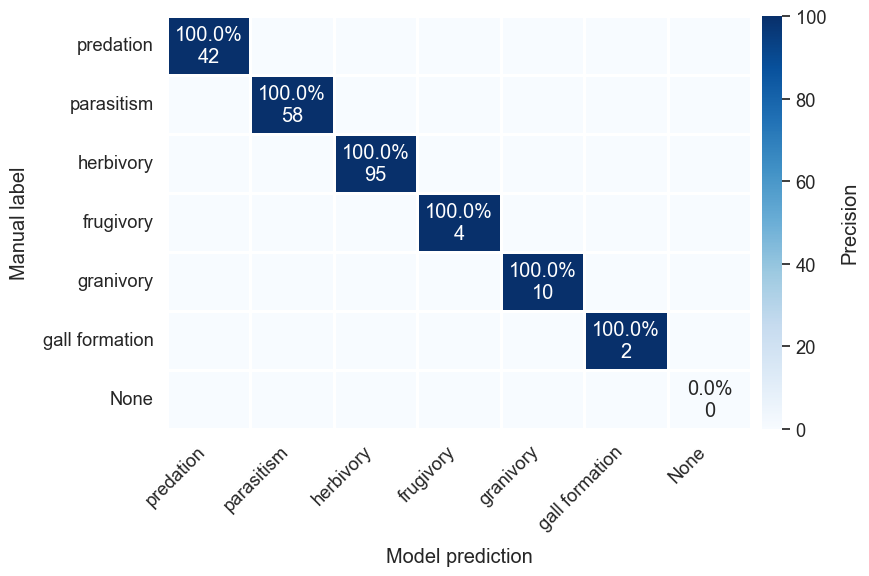



                precision    recall  f1-score   support

     predation      1.000     1.000     1.000        42
    parasitism      1.000     1.000     1.000        58
     herbivory      1.000     1.000     1.000        95
     frugivory      1.000     1.000     1.000         4
     granivory      1.000     1.000     1.000        10
gall formation      1.000     1.000     1.000         2
          None      0.000     0.000     0.000         0

      accuracy                          1.000       211
     macro avg      0.857     0.857     0.857       211
  weighted avg      1.000     1.000     1.000       211



[]

In [53]:
# FEEDING MODE - TEST

mismatches = compute_accuracy(df_test_checked['Feeding Mode'], df_test_generated['Feeding Mode'])

plot_confusion_matrix(df_test_checked['Feeding Mode'],
                      df_test_generated['Feeding Mode'],
                      labels=['predation','parasitism','herbivory','frugivory','granivory','gall formation','None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_feeding_mode_test',
                      font_scale=1.2)
mismatches

support:   804
accuracy:  99.5%
precision: 99.6%
recall:    99.9%
f1:        99.7%


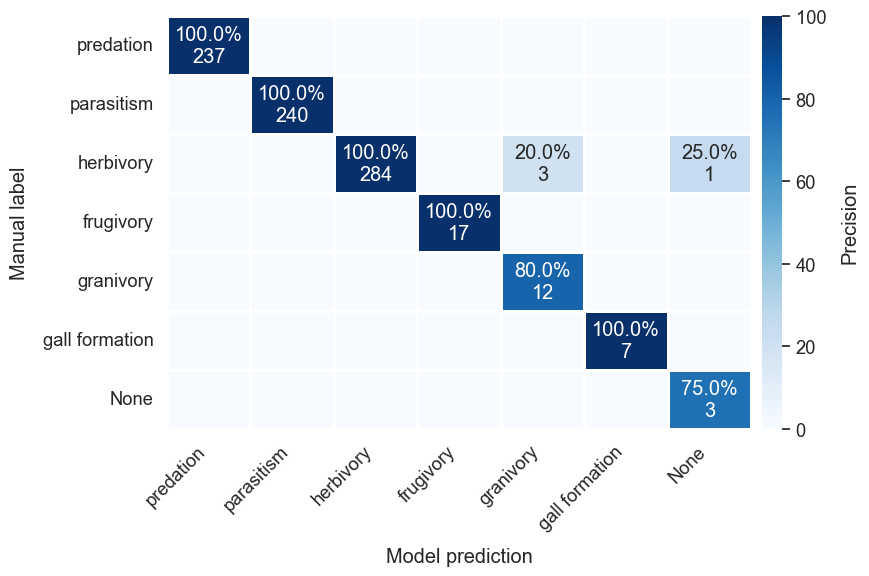



                precision    recall  f1-score   support

     predation      1.000     1.000     1.000       237
    parasitism      1.000     1.000     1.000       240
     herbivory      1.000     0.986     0.993       288
     frugivory      1.000     1.000     1.000        17
     granivory      0.800     1.000     0.889        12
gall formation      1.000     1.000     1.000         7
          None      0.750     1.000     0.857         3

      accuracy                          0.995       804
     macro avg      0.936     0.998     0.963       804
  weighted avg      0.996     0.995     0.995       804



[(387, 'herbivory', 'granivory'),
 (388, 'herbivory', 'granivory'),
 (389, 'herbivory', 'granivory'),
 (415, 'herbivory', 'None')]

In [54]:
# FEEDING MODE - TOTAL

mismatches = compute_accuracy(df_checked['Feeding Mode'], df_generated['Feeding Mode'])

plot_confusion_matrix(df_checked['Feeding Mode'],
                      df_generated['Feeding Mode'],
                      labels=['predation','parasitism','herbivory','frugivory','granivory','gall formation','None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_feeding_mode_total',
                      font_scale=1.2)
mismatches

## Results: Host Plants

In [55]:
def align_nested_lists(ser_manual, ser_generated, column, setFalse=False):
    final_manual = []
    final_generated = []

    # only where manual labels are 'herbivore':
    ser_generated = ser_generated[ser_manual['Type']=='herbivore']
    ser_manual = ser_manual[ser_manual['Type']=='herbivore']
    
    manual_lists = ser_manual[column].fillna('').str.split(',').apply(lambda x: [i.strip() for i in x if i.strip()])
    gen_lists = ser_generated[column].fillna('').str.split(',').apply(lambda x: [i.strip() for i in x if i.strip()])

    if setFalse: 
        manual_lists[manual_lists==''] = False
        manual_lists[manual_lists=='NA'] = False
        gen_lists[gen_lists==''] = False
        gen_lists[gen_lists=='NA'] = False
    else:
        manual_lists[manual_lists==''] = 'None'
        manual_lists[manual_lists=='NA'] = 'None'
        gen_lists[gen_lists==''] = 'None'
        gen_lists[gen_lists=='NA'] = 'None'

    for i in range(len(manual_lists)):
        m_list = manual_lists.iloc[i]
        g_list = gen_lists.iloc[i]

        for j in range(max(len(m_list), len(g_list), 1)):

            try: m_item = m_list[j]
            except: 
                if setFalse: m_item = False
                else: m_item = 'None'
                

            try: g_item = g_list[j]
            except: 
                if setFalse: g_item = False
                else: g_item = 'None'

            final_manual.append(m_item)
            final_generated.append(g_item)


    return np.array(final_manual), np.array(final_generated)

In [56]:
# HOST PLANTS - TRAIN

manual_vec, gen_vec = align_nested_lists(df_train_checked, df_train_generated, 'Host Plants')
mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   247
accuracy:  96.0%
precision: 97.7%
recall:    97.7%
f1:        97.7%


[(36, 'Picea (spruce)', 'None'),
 (37, 'Picea (spruce)', 'None'),
 (61, 'agricultural crops', 'None'),
 (62, 'agricultural crops', 'None'),
 (164, 'Onion (Allium cepa)', 'Garlic (Allium sativum)'),
 (165, 'Onion (Allium cepa)', 'Leek (Allium porrum)'),
 (180, 'None', 'agricultural crops'),
 (181, 'None', 'agricultural crops'),
 (207, 'Carthamus tinctorius (safflower)', 'None'),
 (219, 'fruit (banana and blueberry)', 'agricultural crops')]

In [15]:
# HOST PLANTS - TEST

manual_vec, gen_vec = align_nested_lists(df_test_checked, df_test_generated, 'Host Plants')
mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   145
accuracy:  95.9%
precision: 97.7%
recall:    97.7%
f1:        97.7%


[(84, 'Green bean (Phaseolus vulgaris)', 'None'),
 (102, 'Zea mays', 'Panicum virgatum'),
 (103, 'Miscanthus × giganteus', 'None'),
 (104, 'Panicum virgatum', 'None'),
 (117, 'None', 'agricultural crops'),
 (138, 'None', 'agricultural crops')]

In [16]:
# HOST PLANTS - TOTAL

manual_vec, gen_vec = align_nested_lists(df_checked, df_generated, 'Host Plants')
mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   392
accuracy:  95.9%
precision: 97.7%
recall:    97.7%
f1:        97.7%


[(36, 'Picea (spruce)', 'None'),
 (37, 'Picea (spruce)', 'None'),
 (61, 'agricultural crops', 'None'),
 (62, 'agricultural crops', 'None'),
 (164, 'Onion (Allium cepa)', 'Garlic (Allium sativum)'),
 (165, 'Onion (Allium cepa)', 'Leek (Allium porrum)'),
 (180, 'None', 'agricultural crops'),
 (181, 'None', 'agricultural crops'),
 (207, 'Carthamus tinctorius (safflower)', 'None'),
 (219, 'fruit (banana and blueberry)', 'agricultural crops'),
 (331, 'Green bean (Phaseolus vulgaris)', 'None'),
 (349, 'Zea mays', 'Panicum virgatum'),
 (350, 'Miscanthus × giganteus', 'None'),
 (351, 'Panicum virgatum', 'None'),
 (364, 'None', 'agricultural crops'),
 (385, 'None', 'agricultural crops')]

support:   247
accuracy:  93.9%
precision: 95.4%
recall:    97.6%
f1:        96.5%


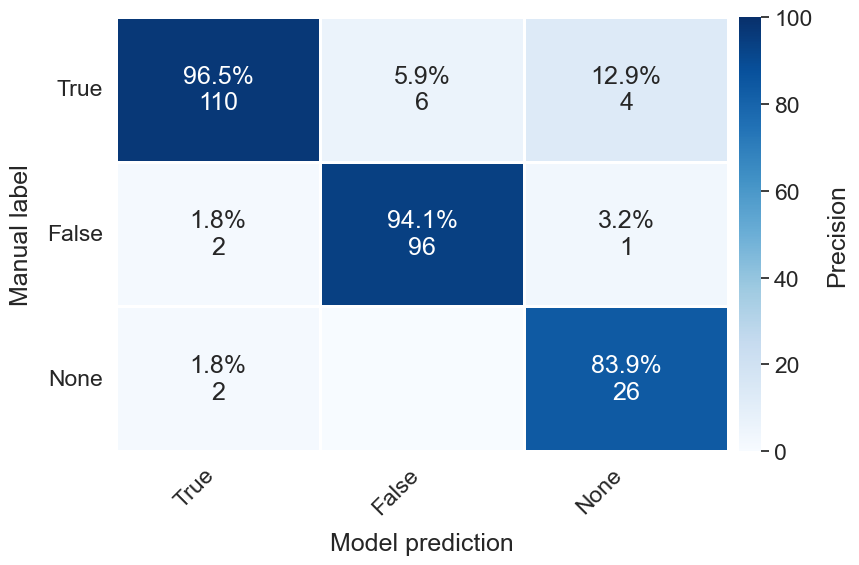



              precision    recall  f1-score   support

        True      0.965     0.917     0.940       120
       False      0.941     0.970     0.955        99
        None      0.839     0.929     0.881        28

    accuracy                          0.939       247
   macro avg      0.915     0.938     0.926       247
weighted avg      0.941     0.939     0.940       247



[(19, 'True', 'False'),
 (36, 'True', 'None'),
 (37, 'False', 'None'),
 (58, 'False', 'True'),
 (61, 'True', 'None'),
 (62, 'True', 'None'),
 (70, 'True', 'False'),
 (128, 'True', 'False'),
 (135, 'True', 'False'),
 (136, 'True', 'False'),
 (180, 'None', 'True'),
 (181, 'None', 'True'),
 (207, 'True', 'None'),
 (233, 'True', 'False'),
 (237, 'False', 'True')]

In [17]:
# IS PEST - TRAIN
manual_vec, gen_vec = align_nested_lists(df_train_checked, df_train_generated, 'Herbivore Is Pest')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['True', 'False','None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_ispest_train')

mismatches

support:   145
accuracy:  91.7%
precision: 93.2%
recall:    97.6%
f1:        95.3%


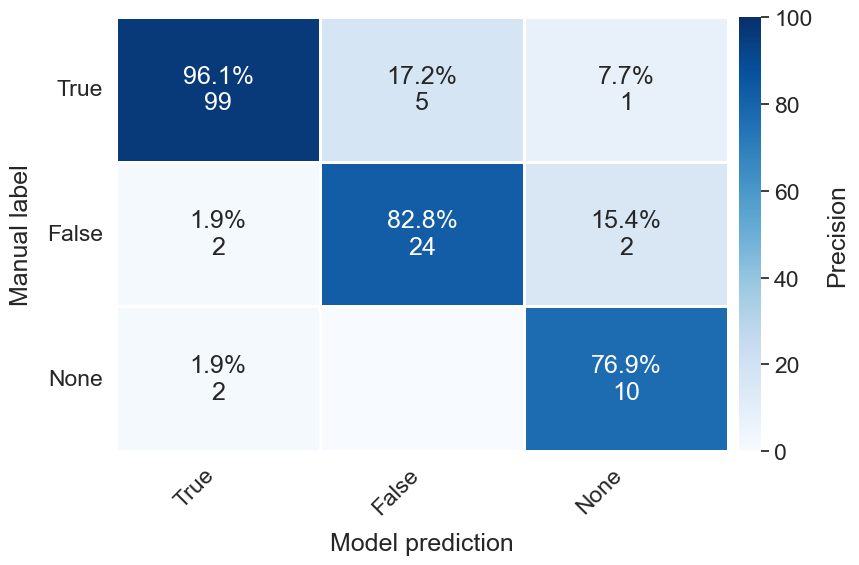



              precision    recall  f1-score   support

        True      0.961     0.943     0.952       105
       False      0.828     0.857     0.842        28
        None      0.769     0.833     0.800        12

    accuracy                          0.917       145
   macro avg      0.853     0.878     0.865       145
weighted avg      0.919     0.917     0.918       145



[(29, 'False', 'True'),
 (30, 'False', 'True'),
 (84, 'True', 'None'),
 (102, 'True', 'False'),
 (103, 'False', 'None'),
 (104, 'False', 'None'),
 (113, 'True', 'False'),
 (114, 'True', 'False'),
 (115, 'True', 'False'),
 (117, 'None', 'True'),
 (138, 'None', 'True'),
 (144, 'True', 'False')]

In [18]:
# IS PEST - TEST
manual_vec, gen_vec = align_nested_lists(df_test_checked, df_test_generated, 'Herbivore Is Pest')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['True', 'False', 'None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_ispest_test')

mismatches

support:   392
accuracy:  93.1%
precision: 94.5%
recall:    97.6%
f1:        96.1%


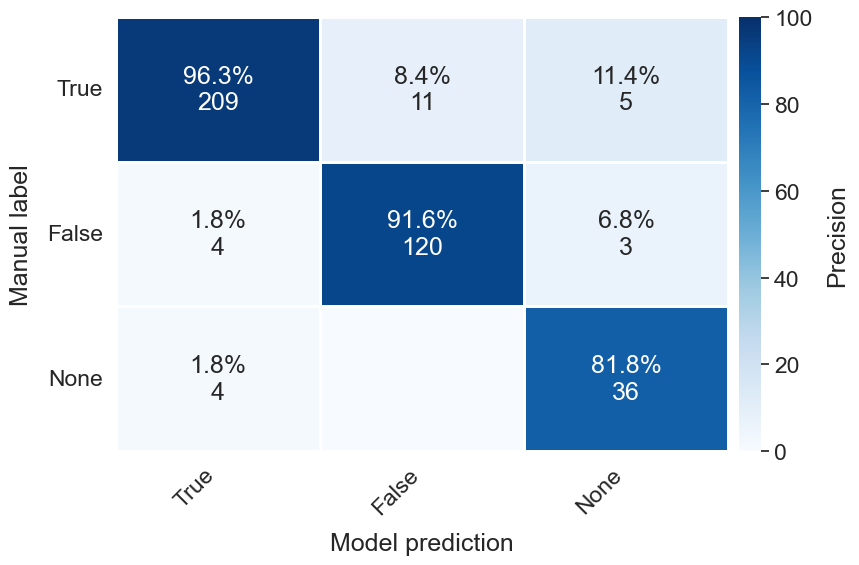



              precision    recall  f1-score   support

        True      0.963     0.929     0.946       225
       False      0.916     0.945     0.930       127
        None      0.818     0.900     0.857        40

    accuracy                          0.931       392
   macro avg      0.899     0.925     0.911       392
weighted avg      0.933     0.931     0.932       392



[(19, 'True', 'False'),
 (36, 'True', 'None'),
 (37, 'False', 'None'),
 (58, 'False', 'True'),
 (61, 'True', 'None'),
 (62, 'True', 'None'),
 (70, 'True', 'False'),
 (128, 'True', 'False'),
 (135, 'True', 'False'),
 (136, 'True', 'False'),
 (180, 'None', 'True'),
 (181, 'None', 'True'),
 (207, 'True', 'None'),
 (233, 'True', 'False'),
 (237, 'False', 'True'),
 (276, 'False', 'True'),
 (277, 'False', 'True'),
 (331, 'True', 'None'),
 (349, 'True', 'False'),
 (350, 'False', 'None'),
 (351, 'False', 'None'),
 (360, 'True', 'False'),
 (361, 'True', 'False'),
 (362, 'True', 'False'),
 (364, 'None', 'True'),
 (385, 'None', 'True'),
 (391, 'True', 'False')]

In [19]:
# IS PEST - TOTAL

manual_vec, gen_vec = align_nested_lists(df_checked, df_generated, 'Herbivore Is Pest')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['True', 'False', 'None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_ispest_total')

mismatches

support:   247
accuracy:  92.7%
precision: 84.7%
recall:    93.5%
f1:        88.9%


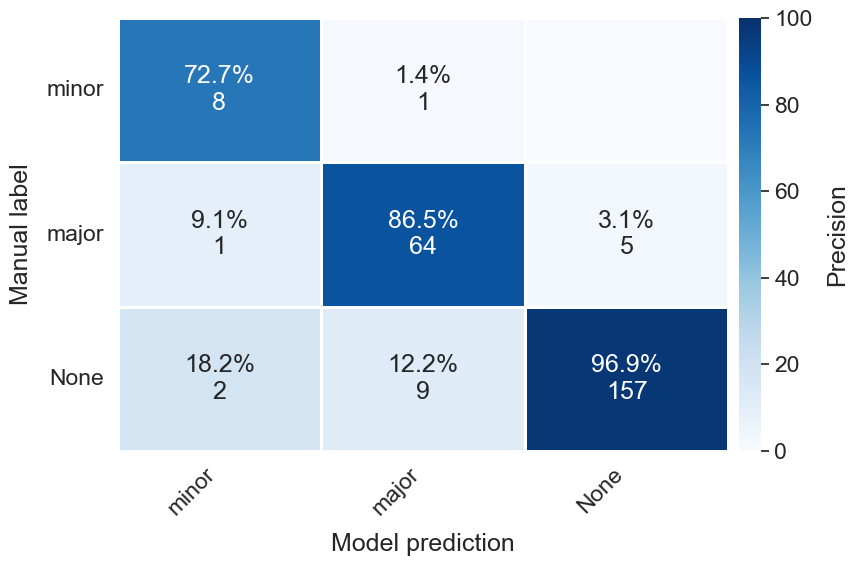



              precision    recall  f1-score   support

       minor      0.727     0.889     0.800         9
       major      0.865     0.914     0.889        70
        None      0.969     0.935     0.952       168

    accuracy                          0.927       247
   macro avg      0.854     0.913     0.880       247
weighted avg      0.931     0.927     0.928       247



[(19, 'major', 'None'),
 (36, 'major', 'None'),
 (38, 'None', 'major'),
 (39, 'None', 'major'),
 (40, 'None', 'major'),
 (41, 'None', 'major'),
 (44, 'major', 'None'),
 (58, 'None', 'minor'),
 (61, 'major', 'None'),
 (62, 'major', 'None'),
 (66, 'None', 'major'),
 (67, 'None', 'major'),
 (72, 'None', 'major'),
 (173, 'major', 'minor'),
 (180, 'None', 'major'),
 (181, 'None', 'major'),
 (236, 'minor', 'major'),
 (237, 'None', 'minor')]

In [20]:
# PEST IMPORTANCE - TRAIN

manual_vec, gen_vec = align_nested_lists(df_train_checked, df_train_generated, 'Pest Importance')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['minor', 'major', 'None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_pest_importance_train')

mismatches

support:   145
accuracy:  93.1%
precision: 94.0%
recall:    95.9%
f1:        94.9%


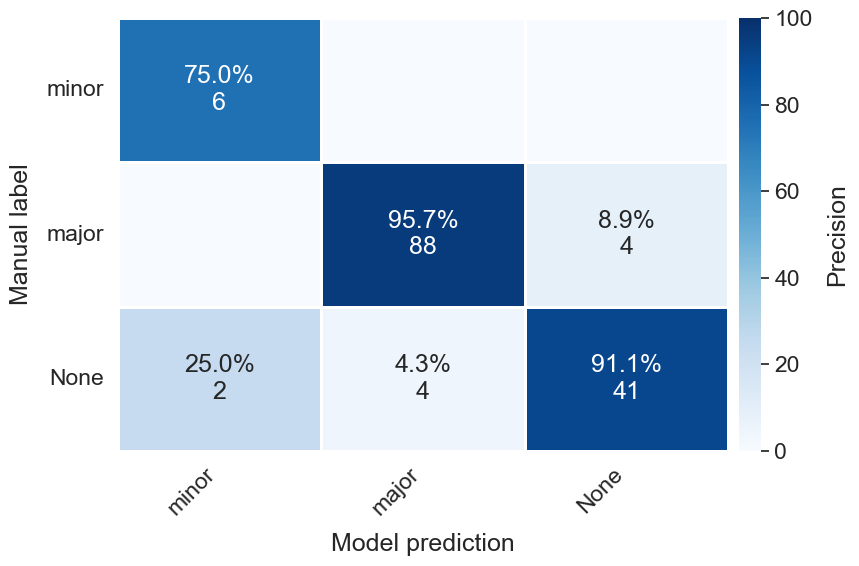



              precision    recall  f1-score   support

       minor      0.750     1.000     0.857         6
       major      0.957     0.957     0.957        92
        None      0.911     0.872     0.891        47

    accuracy                          0.931       145
   macro avg      0.873     0.943     0.902       145
weighted avg      0.933     0.931     0.931       145



[(6, 'None', 'major'),
 (7, 'None', 'major'),
 (29, 'None', 'minor'),
 (30, 'None', 'minor'),
 (97, 'major', 'None'),
 (113, 'major', 'None'),
 (114, 'major', 'None'),
 (115, 'major', 'None'),
 (117, 'None', 'major'),
 (138, 'None', 'major')]

In [21]:
# PEST IMPORTANCE - TEST
manual_vec, gen_vec = align_nested_lists(df_test_checked, df_test_generated, 'Pest Importance')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['minor', 'major', 'None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_pest_importance_test')

mismatches

support:   392
accuracy:  92.9%
precision: 89.7%
recall:    94.9%
f1:        92.2%


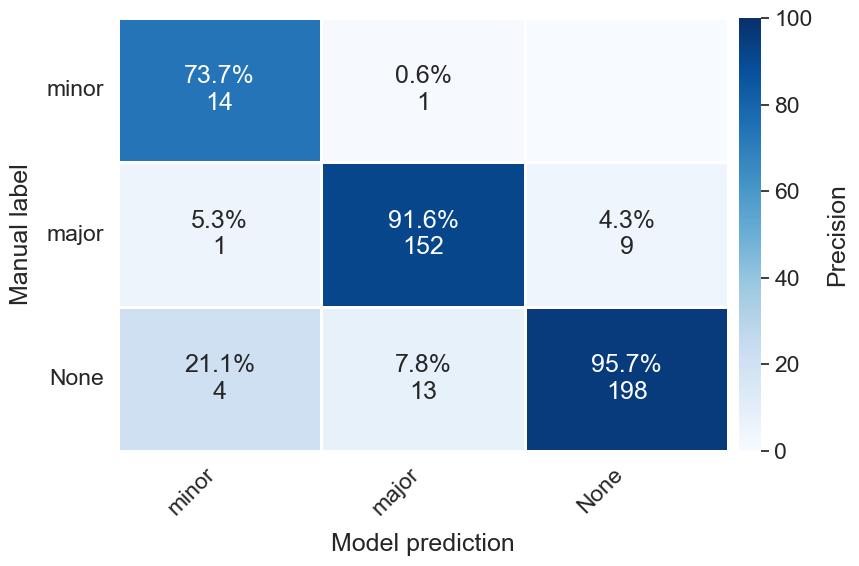



              precision    recall  f1-score   support

       minor      0.737     0.933     0.824        15
       major      0.916     0.938     0.927       162
        None      0.957     0.921     0.938       215

    accuracy                          0.929       392
   macro avg      0.870     0.931     0.896       392
weighted avg      0.931     0.929     0.929       392



[(19, 'major', 'None'),
 (36, 'major', 'None'),
 (38, 'None', 'major'),
 (39, 'None', 'major'),
 (40, 'None', 'major'),
 (41, 'None', 'major'),
 (44, 'major', 'None'),
 (58, 'None', 'minor'),
 (61, 'major', 'None'),
 (62, 'major', 'None'),
 (66, 'None', 'major'),
 (67, 'None', 'major'),
 (72, 'None', 'major'),
 (173, 'major', 'minor'),
 (180, 'None', 'major'),
 (181, 'None', 'major'),
 (236, 'minor', 'major'),
 (237, 'None', 'minor'),
 (253, 'None', 'major'),
 (254, 'None', 'major'),
 (276, 'None', 'minor'),
 (277, 'None', 'minor'),
 (344, 'major', 'None'),
 (360, 'major', 'None'),
 (361, 'major', 'None'),
 (362, 'major', 'None'),
 (364, 'None', 'major'),
 (385, 'None', 'major')]

In [22]:
# PEST IMPORTANCE - TOTAL

manual_vec, gen_vec = align_nested_lists(df_checked, df_generated, 'Pest Importance')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['minor', 'major', 'None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_pest_importance_total')

mismatches

support:   247
accuracy:  95.1%
precision: 96.8%
recall:    97.7%
f1:        97.2%


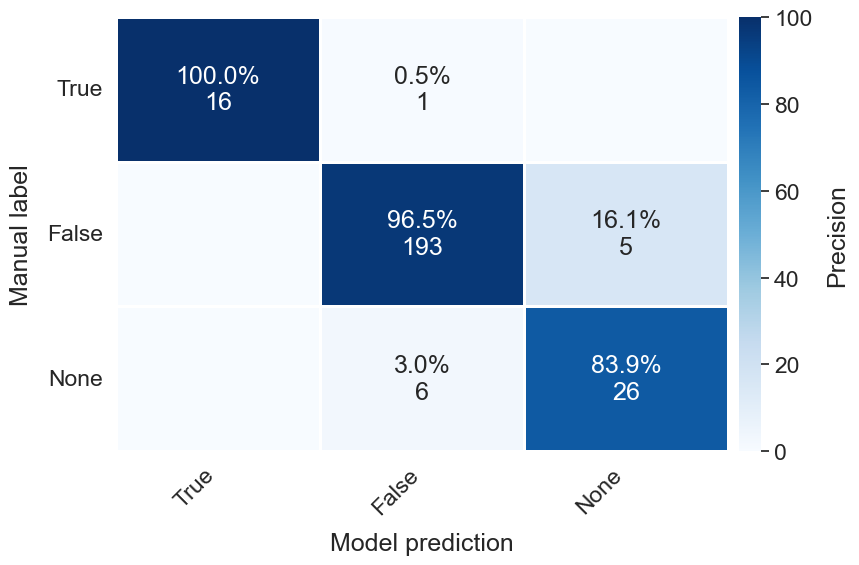



              precision    recall  f1-score   support

        True      1.000     0.941     0.970        17
       False      0.965     0.975     0.970       198
        None      0.839     0.812     0.825        32

    accuracy                          0.951       247
   macro avg      0.935     0.909     0.922       247
weighted avg      0.951     0.951     0.951       247



[(36, 'False', 'None'),
 (37, 'False', 'None'),
 (38, 'None', 'False'),
 (39, 'None', 'False'),
 (40, 'None', 'False'),
 (41, 'None', 'False'),
 (61, 'False', 'None'),
 (62, 'False', 'None'),
 (180, 'None', 'False'),
 (181, 'None', 'False'),
 (207, 'False', 'None'),
 (216, 'True', 'False')]

In [23]:
# IS BCA - TRAIN

manual_vec, gen_vec = align_nested_lists(df_train_checked, df_train_generated, 'Herbivore Is BCA')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['True', 'False', 'None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_bca_train')

mismatches

support:   145
accuracy:  96.6%
precision: 98.5%
recall:    97.7%
f1:        98.1%


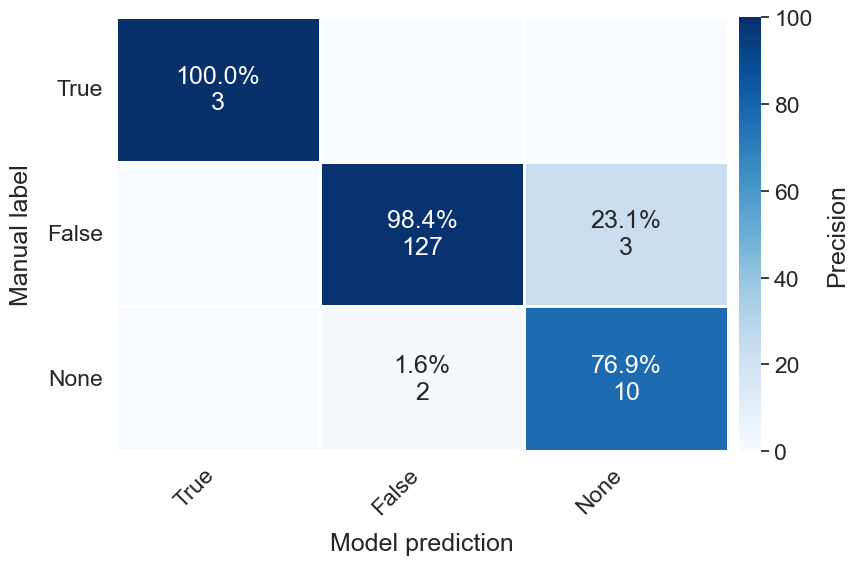



              precision    recall  f1-score   support

        True      1.000     1.000     1.000         3
       False      0.984     0.977     0.981       130
        None      0.769     0.833     0.800        12

    accuracy                          0.966       145
   macro avg      0.918     0.937     0.927       145
weighted avg      0.967     0.966     0.966       145



[(84, 'False', 'None'),
 (103, 'False', 'None'),
 (104, 'False', 'None'),
 (117, 'None', 'False'),
 (138, 'None', 'False')]

In [24]:
# IS BCA - TEST

manual_vec, gen_vec = align_nested_lists(df_test_checked, df_test_generated, 'Herbivore Is BCA')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['True', 'False', 'None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_bca_test')

mismatches

support:   392
accuracy:  95.7%
precision: 97.4%
recall:    97.7%
f1:        97.6%


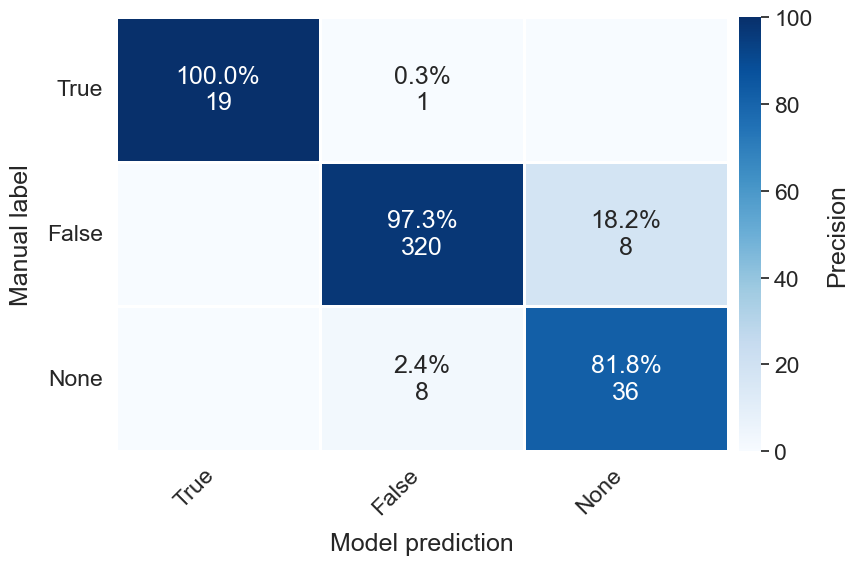



              precision    recall  f1-score   support

        True      1.000     0.950     0.974        20
       False      0.973     0.976     0.974       328
        None      0.818     0.818     0.818        44

    accuracy                          0.957       392
   macro avg      0.930     0.915     0.922       392
weighted avg      0.957     0.957     0.957       392



[(36, 'False', 'None'),
 (37, 'False', 'None'),
 (38, 'None', 'False'),
 (39, 'None', 'False'),
 (40, 'None', 'False'),
 (41, 'None', 'False'),
 (61, 'False', 'None'),
 (62, 'False', 'None'),
 (180, 'None', 'False'),
 (181, 'None', 'False'),
 (207, 'False', 'None'),
 (216, 'True', 'False'),
 (331, 'False', 'None'),
 (350, 'False', 'None'),
 (351, 'False', 'None'),
 (364, 'None', 'False'),
 (385, 'None', 'False')]

In [25]:
# IS BCA - TOTAL

manual_vec, gen_vec = align_nested_lists(df_checked, df_generated, 'Herbivore Is BCA')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['True', 'False', 'None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_bca_total')

mismatches

## Results: Prey Species

In [26]:
def align_nested_lists(ser_manual, ser_generated, column):
    final_manual = []
    final_generated = []

    # only where manual labels are 'natural enemy':
    ser_generated = ser_generated[ser_manual['Type']=='natural enemy']
    ser_manual = ser_manual[ser_manual['Type']=='natural enemy']

    manual_lists = ser_manual[column].fillna('').str.split(',').apply(lambda x: [i.strip() for i in x if i.strip()])
    gen_lists = ser_generated[column].fillna('').str.split(',').apply(lambda x: [i.strip() for i in x if i.strip()])

    manual_lists[manual_lists==''] = 'None'
    manual_lists[manual_lists=='NA'] = 'None'
    gen_lists[gen_lists==''] = 'None'
    gen_lists[gen_lists=='NA'] = 'None'
    
    for i in range(len(manual_lists)):
        m_list = manual_lists.iloc[i]
        g_list = gen_lists.iloc[i]

        for j in range(max(len(m_list), len(g_list), 1)):

            try: m_item = m_list[j]
            except: m_item = 'None'

            try: g_item = g_list[j]
            except: g_item = 'None'

            final_manual.append(m_item)
            final_generated.append(g_item)


    return np.array(final_manual), np.array(final_generated)

In [27]:
# PREY - TRAIN

manual_vec, gen_vec = align_nested_lists(df_train_checked, df_train_generated, 'Herbivore Prey')
mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   533
accuracy:  98.9%
precision: 99.2%
recall:    99.6%
f1:        99.4%


[(138, 'None', 'Deroceras laeve'),
 (139, 'None', 'Deroceras reticulatum'),
 (156, 'Nezara viridula', 'None'),
 (158, 'Nezara viridula', 'None'),
 (336, 'None', 'Cryptoneossa triangula'),
 (338, 'None', 'Eucalyptolyma maideni')]

In [28]:
# PREY - TEST

manual_vec, gen_vec = align_nested_lists(df_test_checked, df_test_generated, 'Herbivore Prey')
mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   124
accuracy:  91.9%
precision: 96.1%
recall:    94.3%
f1:        95.2%


[(22, 'Helicoverpa zea', 'None'),
 (23, 'Helicoverpa zea', 'None'),
 (24, 'Helicoverpa zea', 'None'),
 (25, 'Helicoverpa zea', 'None'),
 (56, 'None', 'Ceutorhynchus obstrictus'),
 (57, 'None', 'Ceutorhynchus obstrictus'),
 (58, 'None', 'Ceutorhynchus obstrictus'),
 (102, 'Tetranychus urticae', 'None'),
 (103, 'Tetranychus urticae', 'None'),
 (108, 'mealybugs', 'Planococcus citri')]

In [29]:
# PREY - TOTAL

manual_vec, gen_vec = align_nested_lists(df_checked, df_generated, 'Herbivore Prey')
mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   657
accuracy:  97.6%
precision: 98.6%
recall:    98.6%
f1:        98.6%


[(138, 'None', 'Deroceras laeve'),
 (139, 'None', 'Deroceras reticulatum'),
 (156, 'Nezara viridula', 'None'),
 (158, 'Nezara viridula', 'None'),
 (336, 'None', 'Cryptoneossa triangula'),
 (338, 'None', 'Eucalyptolyma maideni'),
 (555, 'Helicoverpa zea', 'None'),
 (556, 'Helicoverpa zea', 'None'),
 (557, 'Helicoverpa zea', 'None'),
 (558, 'Helicoverpa zea', 'None'),
 (589, 'None', 'Ceutorhynchus obstrictus'),
 (590, 'None', 'Ceutorhynchus obstrictus'),
 (591, 'None', 'Ceutorhynchus obstrictus'),
 (635, 'Tetranychus urticae', 'None'),
 (636, 'Tetranychus urticae', 'None'),
 (641, 'mealybugs', 'Planococcus citri')]

support:   533
accuracy:  93.6%
precision: 93.3%
recall:    99.6%
f1:        96.3%


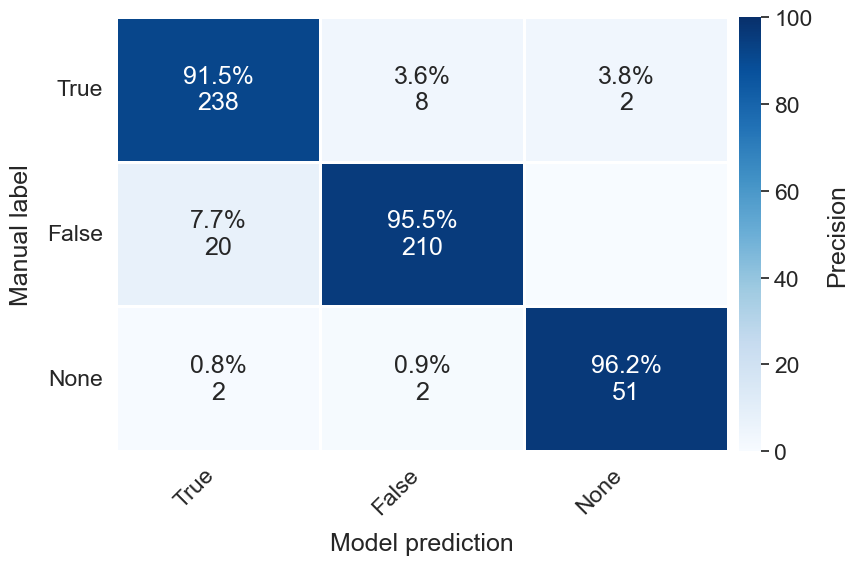



              precision    recall  f1-score   support

        True      0.915     0.960     0.937       248
       False      0.955     0.913     0.933       230
        None      0.962     0.927     0.944        55

    accuracy                          0.936       533
   macro avg      0.944     0.933     0.938       533
weighted avg      0.937     0.936     0.936       533



[(31, 'False', 'True'),
 (32, 'False', 'True'),
 (33, 'False', 'True'),
 (34, 'False', 'True'),
 (35, 'False', 'True'),
 (36, 'False', 'True'),
 (37, 'False', 'True'),
 (38, 'False', 'True'),
 (39, 'False', 'True'),
 (40, 'False', 'True'),
 (41, 'False', 'True'),
 (42, 'False', 'True'),
 (43, 'False', 'True'),
 (44, 'False', 'True'),
 (45, 'False', 'True'),
 (46, 'False', 'True'),
 (56, 'False', 'True'),
 (138, 'None', 'False'),
 (139, 'None', 'False'),
 (156, 'True', 'None'),
 (158, 'True', 'None'),
 (165, 'True', 'False'),
 (166, 'True', 'False'),
 (167, 'True', 'False'),
 (222, 'False', 'True'),
 (223, 'False', 'True'),
 (224, 'False', 'True'),
 (336, 'None', 'True'),
 (338, 'None', 'True'),
 (387, 'True', 'False'),
 (388, 'True', 'False'),
 (389, 'True', 'False'),
 (390, 'True', 'False'),
 (391, 'True', 'False')]

In [30]:
# IMPORTANT ENEMY - TRAIN

manual_vec, gen_vec = align_nested_lists(df_train_checked, df_train_generated, 'Important Natural Enemy')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['True', 'False', 'None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_important_enemy_train')

mismatches

support:   124
accuracy:  87.9%
precision: 91.3%
recall:    94.0%
f1:        92.6%


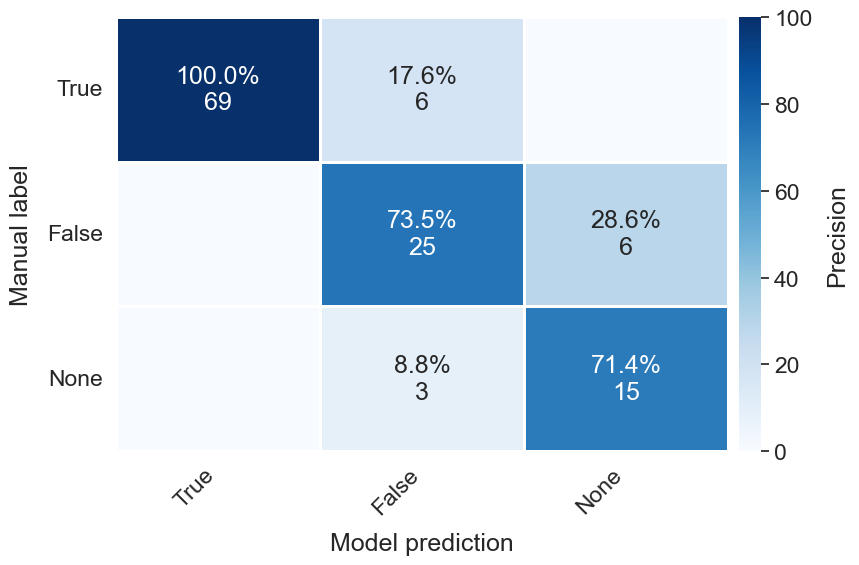



              precision    recall  f1-score   support

        True      1.000     0.920     0.958        75
       False      0.735     0.806     0.769        31
        None      0.714     0.833     0.769        18

    accuracy                          0.879       124
   macro avg      0.817     0.853     0.832       124
weighted avg      0.892     0.879     0.884       124



[(22, 'False', 'None'),
 (23, 'False', 'None'),
 (24, 'False', 'None'),
 (25, 'False', 'None'),
 (56, 'None', 'False'),
 (57, 'None', 'False'),
 (58, 'None', 'False'),
 (59, 'True', 'False'),
 (60, 'True', 'False'),
 (61, 'True', 'False'),
 (62, 'True', 'False'),
 (63, 'True', 'False'),
 (64, 'True', 'False'),
 (102, 'False', 'None'),
 (103, 'False', 'None')]

In [31]:
# IMPORTANT ENEMY - TEST

manual_vec, gen_vec = align_nested_lists(df_test_checked, df_test_generated, 'Important Natural Enemy')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['True', 'False', 'None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_important_enemy_test')

mismatches

support:   657
accuracy:  92.5%
precision: 93.0%
recall:    98.5%
f1:        95.7%


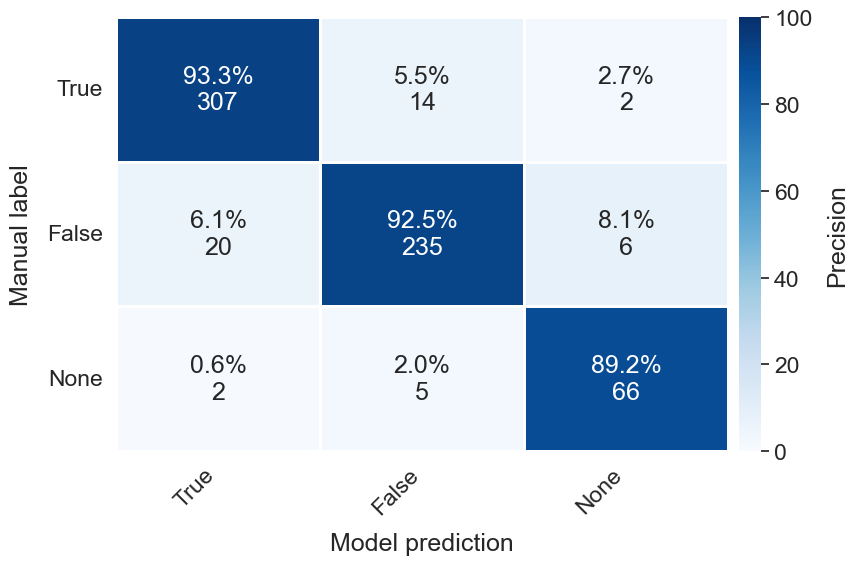



              precision    recall  f1-score   support

        True      0.933     0.950     0.942       323
       False      0.925     0.900     0.913       261
        None      0.892     0.904     0.898        73

    accuracy                          0.925       657
   macro avg      0.917     0.918     0.917       657
weighted avg      0.925     0.925     0.925       657



[(31, 'False', 'True'),
 (32, 'False', 'True'),
 (33, 'False', 'True'),
 (34, 'False', 'True'),
 (35, 'False', 'True'),
 (36, 'False', 'True'),
 (37, 'False', 'True'),
 (38, 'False', 'True'),
 (39, 'False', 'True'),
 (40, 'False', 'True'),
 (41, 'False', 'True'),
 (42, 'False', 'True'),
 (43, 'False', 'True'),
 (44, 'False', 'True'),
 (45, 'False', 'True'),
 (46, 'False', 'True'),
 (56, 'False', 'True'),
 (138, 'None', 'False'),
 (139, 'None', 'False'),
 (156, 'True', 'None'),
 (158, 'True', 'None'),
 (165, 'True', 'False'),
 (166, 'True', 'False'),
 (167, 'True', 'False'),
 (222, 'False', 'True'),
 (223, 'False', 'True'),
 (224, 'False', 'True'),
 (336, 'None', 'True'),
 (338, 'None', 'True'),
 (387, 'True', 'False'),
 (388, 'True', 'False'),
 (389, 'True', 'False'),
 (390, 'True', 'False'),
 (391, 'True', 'False'),
 (555, 'False', 'None'),
 (556, 'False', 'None'),
 (557, 'False', 'None'),
 (558, 'False', 'None'),
 (589, 'None', 'False'),
 (590, 'None', 'False'),
 (591, 'None', 'False

In [32]:
# IMPORTANT ENEMY - TOTAL

manual_vec, gen_vec = align_nested_lists(df_checked, df_generated, 'Important Natural Enemy')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['True', 'False', 'None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_important_enemy_total')

mismatches

support:   533
accuracy:  96.8%
precision: 96.9%
recall:    99.6%
f1:        98.2%


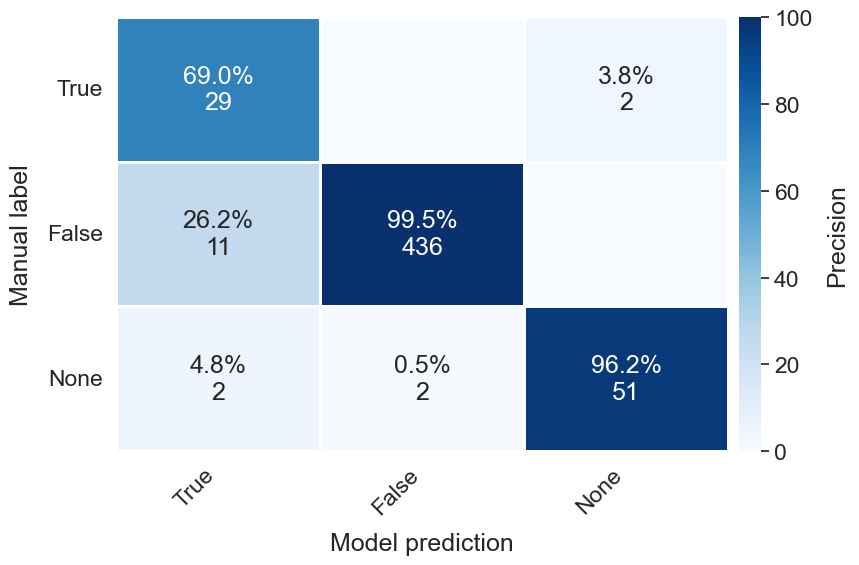



              precision    recall  f1-score   support

        True      0.690     0.935     0.795        31
       False      0.995     0.975     0.985       447
        None      0.962     0.927     0.944        55

    accuracy                          0.968       533
   macro avg      0.883     0.946     0.908       533
weighted avg      0.974     0.968     0.970       533



[(55, 'False', 'True'),
 (61, 'False', 'True'),
 (138, 'None', 'False'),
 (139, 'None', 'False'),
 (156, 'True', 'None'),
 (158, 'True', 'None'),
 (225, 'False', 'True'),
 (247, 'False', 'True'),
 (248, 'False', 'True'),
 (336, 'None', 'True'),
 (338, 'None', 'True'),
 (429, 'False', 'True'),
 (430, 'False', 'True'),
 (441, 'False', 'True'),
 (442, 'False', 'True'),
 (443, 'False', 'True'),
 (444, 'False', 'True')]

In [33]:
# BIOCONTROL - TRAIN

manual_vec, gen_vec = align_nested_lists(df_train_checked, df_train_generated, 'Biological Control')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['True', 'False', 'None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_biocontrol_train')

mismatches

support:   124
accuracy:  83.9%
precision: 86.4%
recall:    93.7%
f1:        89.9%


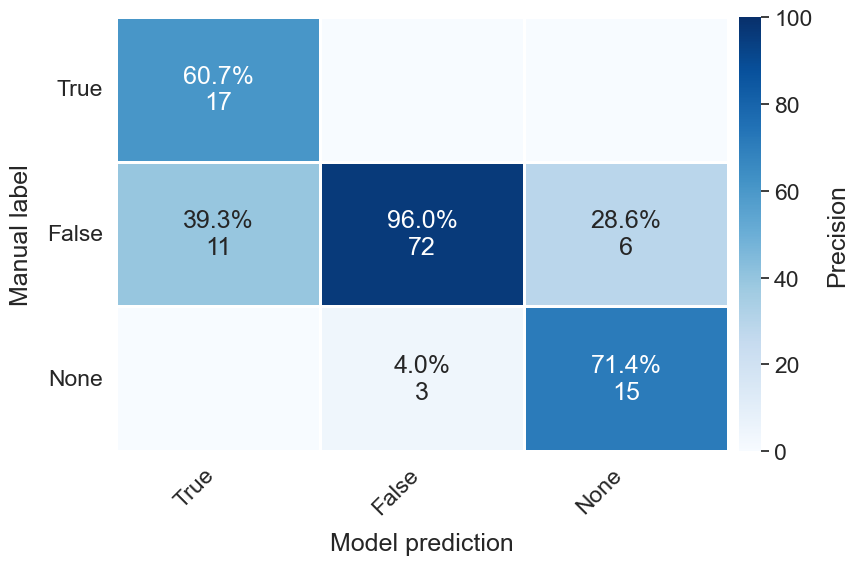



              precision    recall  f1-score   support

        True      0.607     1.000     0.756        17
       False      0.960     0.809     0.878        89
        None      0.714     0.833     0.769        18

    accuracy                          0.839       124
   macro avg      0.760     0.881     0.801       124
weighted avg      0.876     0.839     0.845       124



[(22, 'False', 'None'),
 (23, 'False', 'None'),
 (24, 'False', 'None'),
 (25, 'False', 'None'),
 (56, 'None', 'False'),
 (57, 'None', 'False'),
 (58, 'None', 'False'),
 (78, 'False', 'True'),
 (79, 'False', 'True'),
 (80, 'False', 'True'),
 (81, 'False', 'True'),
 (82, 'False', 'True'),
 (83, 'False', 'True'),
 (84, 'False', 'True'),
 (85, 'False', 'True'),
 (86, 'False', 'True'),
 (102, 'False', 'None'),
 (103, 'False', 'None'),
 (112, 'False', 'True'),
 (123, 'False', 'True')]

In [34]:
# BIOCONTROL - TEST

manual_vec, gen_vec = align_nested_lists(df_test_checked, df_test_generated, 'Biological Control')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['True', 'False', 'None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_biocontrol_test')

mismatches

support:   657
accuracy:  94.4%
precision: 95.0%
recall:    98.6%
f1:        96.8%


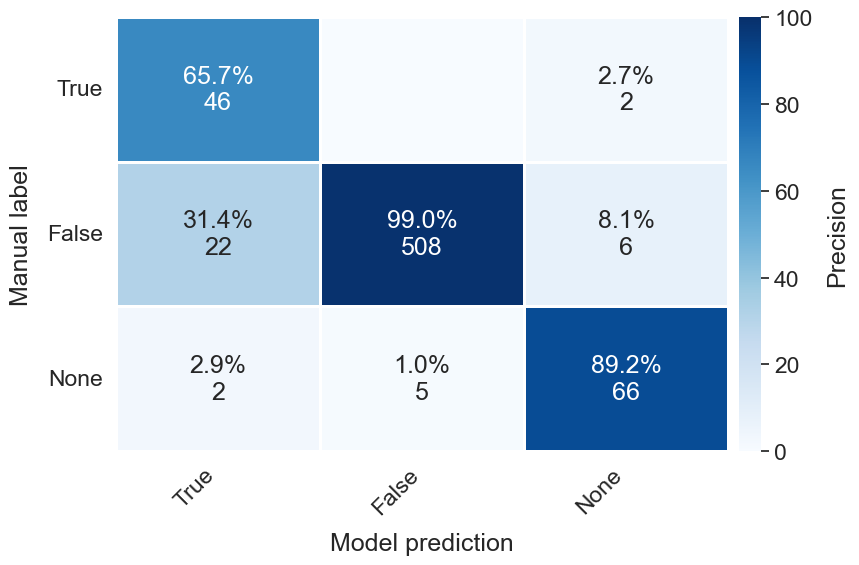



              precision    recall  f1-score   support

        True      0.657     0.958     0.780        48
       False      0.990     0.948     0.969       536
        None      0.892     0.904     0.898        73

    accuracy                          0.944       657
   macro avg      0.846     0.937     0.882       657
weighted avg      0.955     0.944     0.947       657



[(55, 'False', 'True'),
 (61, 'False', 'True'),
 (138, 'None', 'False'),
 (139, 'None', 'False'),
 (156, 'True', 'None'),
 (158, 'True', 'None'),
 (225, 'False', 'True'),
 (247, 'False', 'True'),
 (248, 'False', 'True'),
 (336, 'None', 'True'),
 (338, 'None', 'True'),
 (429, 'False', 'True'),
 (430, 'False', 'True'),
 (441, 'False', 'True'),
 (442, 'False', 'True'),
 (443, 'False', 'True'),
 (444, 'False', 'True'),
 (555, 'False', 'None'),
 (556, 'False', 'None'),
 (557, 'False', 'None'),
 (558, 'False', 'None'),
 (589, 'None', 'False'),
 (590, 'None', 'False'),
 (591, 'None', 'False'),
 (611, 'False', 'True'),
 (612, 'False', 'True'),
 (613, 'False', 'True'),
 (614, 'False', 'True'),
 (615, 'False', 'True'),
 (616, 'False', 'True'),
 (617, 'False', 'True'),
 (618, 'False', 'True'),
 (619, 'False', 'True'),
 (635, 'False', 'None'),
 (636, 'False', 'None'),
 (645, 'False', 'True'),
 (656, 'False', 'True')]

In [35]:
# BIOCONTROL - TOTAL

manual_vec, gen_vec = align_nested_lists(df_checked, df_generated, 'Biological Control')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['True', 'False', 'None'], 
                      figsize=(9,6), 
                      xrot=45, 
                      filename='cm_biocontrol_total')

mismatches

In [36]:
# ASSOCIATED PLANTS - TRAIN
manual_vec, gen_vec = align_nested_lists(df_train_checked, df_train_generated, 'Associated Plants')
mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   461
accuracy:  99.1%
precision: 98.9%
recall:    100.0%
f1:        99.5%


[(147, 'major agronomic and horticultural crops', 'tobacco'),
 (148, 'major agronomic and horticultural crops', 'tobacco'),
 (236, 'None', 'Zea mays'),
 (237, 'None', 'Zea mays')]

In [37]:
# ASSOCIATED PLANTS - TEST
manual_vec, gen_vec = align_nested_lists(df_test_checked, df_test_generated, 'Associated Plants')
mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   106
accuracy:  96.2%
precision: 95.1%
recall:    100.0%
f1:        97.5%


[(48, 'None', 'Brassica spp.'),
 (49, 'None', 'Brassica spp.'),
 (50, 'None', 'Brassica spp.'),
 (65, 'None', 'Brassica oleracea')]

In [38]:
# ASSOCIATED PLANTS - TOTAL
manual_vec, gen_vec = align_nested_lists(df_checked, df_generated, 'Associated Plants')
mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   567
accuracy:  98.6%
precision: 98.2%
recall:    100.0%
f1:        99.1%


[(147, 'major agronomic and horticultural crops', 'tobacco'),
 (148, 'major agronomic and horticultural crops', 'tobacco'),
 (236, 'None', 'Zea mays'),
 (237, 'None', 'Zea mays'),
 (509, 'None', 'Brassica spp.'),
 (510, 'None', 'Brassica spp.'),
 (511, 'None', 'Brassica spp.'),
 (526, 'None', 'Brassica oleracea')]

In [39]:
# HYPERPARASITOIDS - TRAIN
manual_vec, gen_vec = align_nested_lists(df_train_checked, df_train_generated, 'Hyperparasitoids')
mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   447
accuracy:  100.0%
precision: 100.0%
recall:    100.0%
f1:        100.0%


[]

In [40]:
# HYPERPARASITOIDS - TEST
manual_vec, gen_vec = align_nested_lists(df_test_checked, df_test_generated, 'Hyperparasitoids')
mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   101
accuracy:  100.0%
precision: 100.0%
recall:    100.0%
f1:        100.0%


[]

In [41]:
# HYPERPARASITOIDS - TOTAL
manual_vec, gen_vec = align_nested_lists(df_checked, df_generated, 'Hyperparasitoids')
mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   548
accuracy:  100.0%
precision: 100.0%
recall:    100.0%
f1:        100.0%


[]

In [42]:
def align_nested_lists(ser_manual, ser_generated, column):
    final_manual = []
    final_generated = []

    manual_lists = ser_manual[column].fillna('').str.split(',').apply(lambda x: [i.strip() for i in x if i.strip()])
    gen_lists = ser_generated[column].fillna('').str.split(',').apply(lambda x: [i.strip() for i in x if i.strip()])

    manual_lists[manual_lists==''] = 'None'
    manual_lists[manual_lists=='NA'] = 'None'
    gen_lists[gen_lists==''] = 'None'
    gen_lists[gen_lists=='NA'] = 'None'
    
    for i in range(len(manual_lists)):
        m_list = manual_lists.iloc[i]
        g_list = gen_lists.iloc[i]

        for j in range(max(len(m_list), len(g_list), 1)):

            try: m_item = m_list[j]
            except: m_item = 'None'

            try: g_item = g_list[j]
            except: g_item = 'None'

            final_manual.append(m_item)
            final_generated.append(g_item)


    return np.array(final_manual), np.array(final_generated)

In [43]:
# INVASIVE IN - TRAIN

manual_vec, gen_vec = align_nested_lists(df_train_checked, df_train_generated, 'Invasive')
mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   598
accuracy:  100.0%
precision: 100.0%
recall:    100.0%
f1:        100.0%


[]

In [44]:
# INVASIVE IN - TEST

manual_vec, gen_vec = align_nested_lists(df_test_checked, df_test_generated, 'Invasive')

# merge elements Massachusetts and USA to 'Massachusetts, USA'
manual_vec = np.concatenate([manual_vec[:185], [f"{manual_vec[185]}, {manual_vec[186]}"], manual_vec[187:]]) 
gen_vec = np.concatenate([gen_vec[:185], [f"{gen_vec[185]}, {gen_vec[186]}"], gen_vec[187:]]) 

mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   213
accuracy:  99.1%
precision: 75.0%
recall:    100.0%
f1:        85.7%


[(148, 'None', 'North America'), (150, 'None', 'Europe')]

In [45]:
# INVASIVE IN - TOTAL

manual_vec, gen_vec = align_nested_lists(df_checked, df_generated, 'Invasive')

# merge elements Massachusetts and USA to 'Massachusetts, USA'
manual_vec = np.concatenate([manual_vec[:782], [f"{manual_vec[782]}, {manual_vec[783]}"], manual_vec[784:]]) 
gen_vec = np.concatenate([gen_vec[:782], [f"{gen_vec[782]}, {gen_vec[783]}"], gen_vec[784:]]) 


mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   811
accuracy:  99.8%
precision: 90.0%
recall:    100.0%
f1:        94.7%


[(746, 'None', 'North America'), (748, 'None', 'Europe')]

In [46]:
# VECTORS - TRAIN

manual_vec, gen_vec = align_nested_lists(df_train_checked, df_train_generated, 'Vectors')
mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   593
accuracy:  99.7%
precision: 100.0%
recall:    80.0%
f1:        88.9%


[(361, 'grapevine leafroll disease', 'None'),
 (362, 'grapevine leafroll disease', 'None')]

In [47]:
# VECTORS - TEST

manual_vec, gen_vec = align_nested_lists(df_test_checked, df_test_generated, 'Vectors')
mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   211
accuracy:  100.0%
precision: 100.0%
recall:    100.0%
f1:        100.0%


[]

In [48]:
# VECTORS - TOTAL

manual_vec, gen_vec = align_nested_lists(df_checked, df_generated, 'Vectors')
mismatches = compute_accuracy(manual_vec, gen_vec)
mismatches

support:   804
accuracy:  99.8%
precision: 100.0%
recall:    83.3%
f1:        90.9%


[(361, 'grapevine leafroll disease', 'None'),
 (362, 'grapevine leafroll disease', 'None')]

support:   224
accuracy:  91.5%
precision: 93.9%
recall:    96.4%
f1:        95.1%


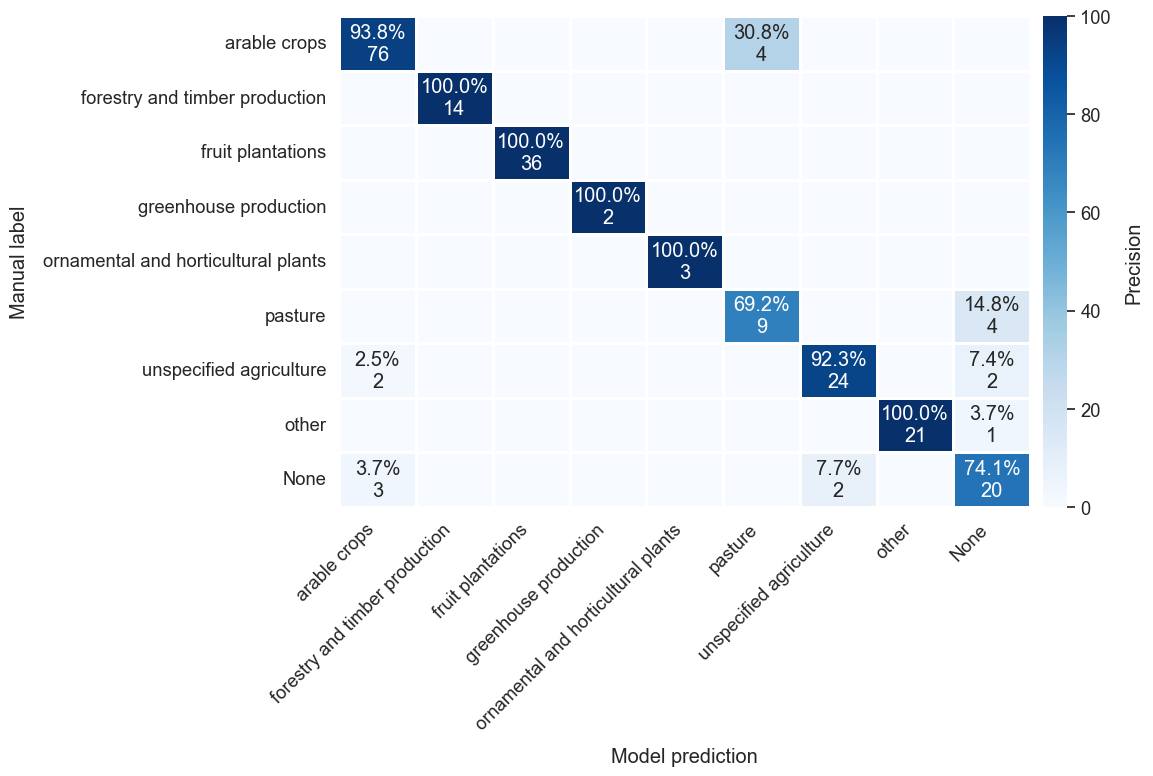



                                     precision    recall  f1-score   support

                       arable crops      0.938     0.938     0.938        81
     forestry and timber production      1.000     1.000     1.000        14
                  fruit plantations      1.000     1.000     1.000        36
              greenhouse production      1.000     1.000     1.000         2
ornamental and horticultural plants      1.000     1.000     1.000         3
                            pasture      0.692     0.692     0.692        13
            unspecified agriculture      0.923     0.857     0.889        28
                              other      1.000     0.955     0.977        22
                               None      0.741     0.800     0.769        25

                          micro avg      0.919     0.915     0.917       224
                          macro avg      0.922     0.916     0.918       224
                       weighted avg      0.921     0.915     0.918      

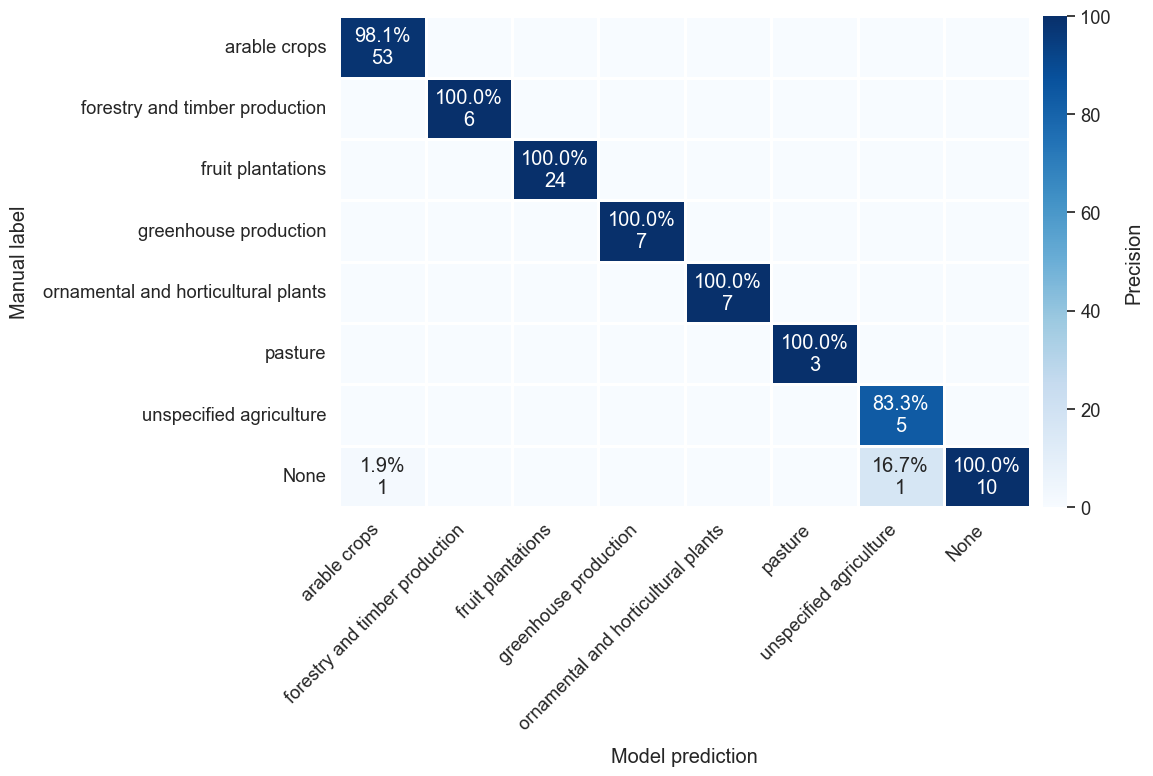



                                     precision    recall  f1-score   support

                       arable crops      0.981     1.000     0.991        53
     forestry and timber production      1.000     1.000     1.000         6
                  fruit plantations      1.000     1.000     1.000        24
              greenhouse production      1.000     1.000     1.000         7
ornamental and horticultural plants      1.000     1.000     1.000         7
                            pasture      1.000     1.000     1.000         3
            unspecified agriculture      0.833     1.000     0.909         5
                               None      1.000     0.833     0.909        12

                          micro avg      0.983     0.983     0.983       117
                          macro avg      0.977     0.979     0.976       117
                       weighted avg      0.984     0.983     0.983       117

support:   349
accuracy:  94.0%
precision: 95.5%
recall:    97.7%
f1:  

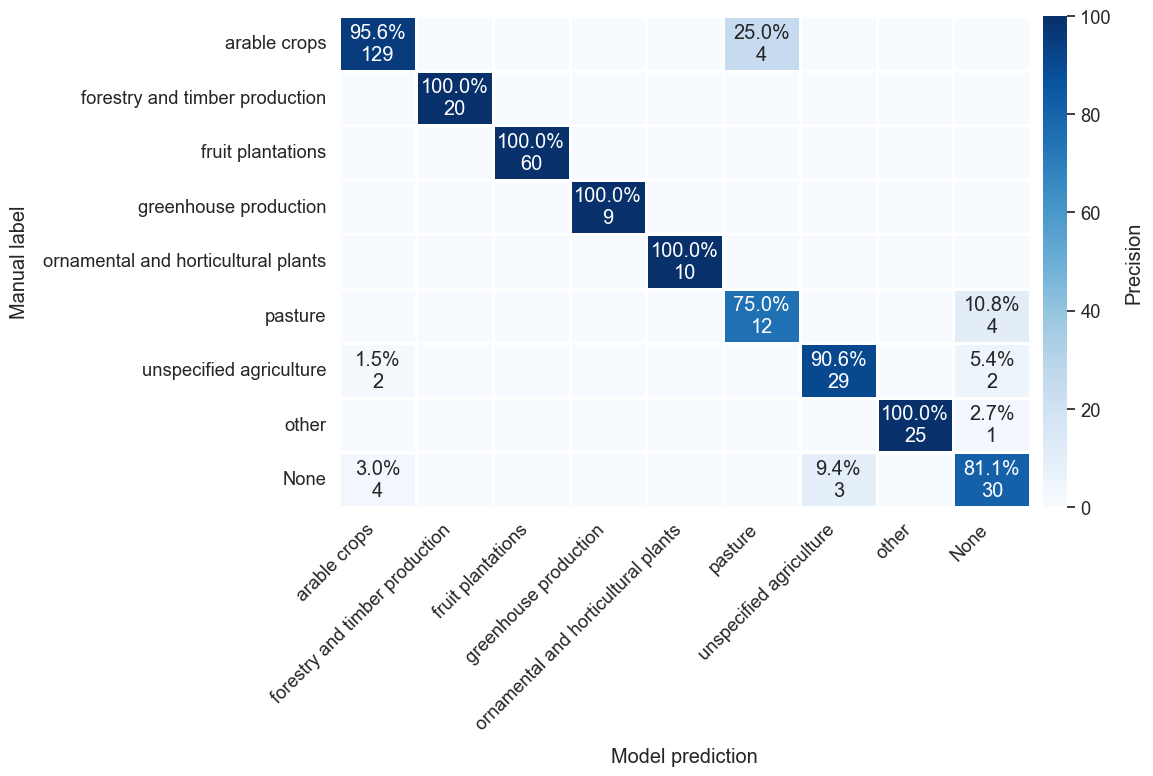



                                     precision    recall  f1-score   support

                       arable crops      0.956     0.963     0.959       134
     forestry and timber production      1.000     1.000     1.000        20
                  fruit plantations      1.000     1.000     1.000        60
              greenhouse production      1.000     1.000     1.000         9
ornamental and horticultural plants      1.000     1.000     1.000        10
                            pasture      0.750     0.750     0.750        16
            unspecified agriculture      0.906     0.879     0.892        33
                              other      1.000     0.962     0.980        26
                               None      0.811     0.811     0.811        37

                          micro avg      0.942     0.939     0.940       345
                          macro avg      0.936     0.929     0.933       345
                       weighted avg      0.942     0.939     0.940      

[(8, 'None', 'unspecified agriculture'),
 (41, 'arable crops', 'pasture'),
 (42, 'pasture', 'None'),
 (61, 'unspecified agriculture', 'None'),
 (62, 'unspecified agriculture', 'None'),
 (73, 'unspecified agriculture', 'arable crops'),
 (74, 'arable crops', 'pasture'),
 (75, 'pasture', 'None'),
 (76, 'arable crops', 'pasture'),
 (77, 'pasture', 'None'),
 (78, 'arable crops', 'pasture'),
 (79, 'pasture', 'None'),
 (82, 'unspecified agriculture', 'arable crops'),
 (138, 'None', 'unspecified agriculture'),
 (141, 'arable crops', 'arberry crops'),
 (159, 'None', 'arable crops'),
 (160, 'None', 'arable crops'),
 (164, 'None', 'arable crops'),
 (212, 'other', 'None'),
 (322, 'None', 'arable crops'),
 (342, 'None', 'unspecified agriculture')]

In [58]:
# ASSOCIATED INDUSTRIES - TRAIN
manual_vec, gen_vec = align_nested_lists(df_train_checked, df_train_generated, 'Associated Industries')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['arable crops', 'forestry and timber production', 'fruit plantations',
                              'greenhouse production', 'ornamental and horticultural plants',
                              'pasture', 'unspecified agriculture', 'other', 'None'], 
                      figsize=(12,8), 
                      xrot=45, 
                      filename='cm_industries_train',
                      font_scale=1.2)
mismatches

# ASSOCIATED INDUSTRIES - TEST
manual_vec, gen_vec = align_nested_lists(df_test_checked, df_test_generated, 'Associated Industries')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['arable crops', 'forestry and timber production', 'fruit plantations',
                              'greenhouse production', 'ornamental and horticultural plants',
                              'pasture', 'unspecified agriculture', 'None'], 
                      figsize=(12,8), 
                      xrot=45, 
                      filename='cm_industries_test',
                      font_scale=1.2)
mismatches

# ASSOCIATED INDUSTRIES - TOTAL
manual_vec, gen_vec = align_nested_lists(df_checked, df_generated, 'Associated Industries')
mismatches = compute_accuracy(manual_vec, gen_vec)

plot_confusion_matrix(manual_vec,
                      gen_vec, 
                      labels=['arable crops', 'forestry and timber production', 'fruit plantations',
                              'greenhouse production', 'ornamental and horticultural plants',
                              'pasture', 'unspecified agriculture', 'other', 'None'], 
                      figsize=(12,8), 
                      xrot=45, 
                      filename='cm_industries_total',
                      font_scale=1.2)
mismatches